# SDG validation notebook for DIF-PI

This notebook validates the Synthetic Data Generation (SDG)) module used in the DIF-PI framework and aligns the evaluation with the experiments from the paper “Synthetic Time Series Generation for Decision Intelligence Using Large Language Models”.

## What this notebook does

1. loads the dunnhumby - Complete Journey panel exported by `eda-complete-journey.ipynb`;
2. reuses the DIF-PI SKU split logic to obtain consistent `TRAIN_SKUs`, `TEST_SKUs`, and `CASE_SKU`;
3. loads the saved SDG checkpoint from `artifacts/models/`;
4. generates synthetic futures for the case SKU and evaluation SKUs;
5. computes validation metrics and aggregate summaries;
6. evaluates the proposed SDG against the benchmark generators:
   - *GAN*;
   - *TimeGAN*;
   - *DGAN*;
   - *LSTM*.
7. prepares the result tables and figures for the thesis experiments section.

## Input

- a previously trained SDG checkpoint under `artifacts/models/sdg_chronos_t5_small_dunnhumby`

## Output

- fidelity tables and summaries for the proposed SDG and benchmark generators
- utility results based on downstream predictive evaluation
- privacy diagnostics and privacy-against-inference results
- case-study outputs for the selected SKU
- aggregate evaluation results for the held-out test SKUs
- exported tables and figures that can be reused in the thesis chapter and appendices

## 1) Environment and validation configuration

This section sets the paths, the DIF-PI-compatible split parameters, and the saved SDG model settings used for inference and validation only.


In [ ]:
from pathlib import Path
import json
import platform
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hashlib

# Repository imports
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.sdg import LLMSyntheticTimeSeriesGenerator, compute_difpi_sku_split
from src.sdg_compare_utils import (
    average_cosine_similarity,
    average_jensen_shannon_distance,
    build_eval_cases,
    build_train_windows,
    comparison_summary_table,
    detection_auc,
    evaluate_generator_on_cases,
    js_distance_from_hist,
    lag_acf,
    make_daily_series,
    privacy_gain_summary,
    privacy_proxy,
    summarize_windows,
    tstr_trts_metrics,
    windows_to_feature_dataframe,
)

# Paths
PANEL_PATH = REPO_ROOT / "datasets" / "processed" / "difpi_pricing_demand_panel.csv"
OUT_DIR = REPO_ROOT / "artifacts" / "sdg_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Standardized columns
SKU_COL = "StockCode"
TIME_COL = "timestamp"
PRICE_COL = "price"
DEMAND_COL = "demand"

# DIF-PI split protocol
ELIGIBILITY_MODE = "adaptive"
MIN_HISTORY_DAYS_STRICT = 365
MIN_NONZERO_DAYS_STRICT = 60
MIN_HISTORY_DAYS_RELAXED = 120
MIN_NONZERO_DAYS_RELAXED = 30
SKU_HOLDOUT_ENABLED = True
TEST_SKU_FRAC = 0.20
SPLIT_SEED = 42
CASE_SKU_OVERRIDE = None
TARGET_ELIGIBLE_FRACTION = 0.8
HORIZON = 30
TRANSFORMER_SEQ_LEN = 30

# Proposed SDG checkpoint + inference settings
MODEL_NAME = "amazon/chronos-t5-small"
SDG_MODEL_DIR = REPO_ROOT / "artifacts" / "models" / "sdg_chronos_t5_small_dunnhumby"

CONTEXT_LENGTH = 140
PREDICTION_LENGTH = HORIZON
STRIDE = 1
INCLUDE_METADATA = False

PROPOSED_SDG_GENERATION_KWARGS = {
    "num_return_sequences": 48,
    "do_sample": True,
    "temperature": 1.05,
    "top_p": 0.90,
    "top_k": 100,
    "repetition_penalty": 1.12,
    "apply_seasonal_calibration": True,
}

SEASONALITY_STRENGTH = 0.60
MAX_EVAL_TEST_SKUS = None

print("PLATFORM:", platform.platform())
print("PANEL_PATH:", PANEL_PATH)
print("OUT_DIR:", OUT_DIR)
print("MODEL_NAME:", MODEL_NAME)
print("SDG_MODEL_DIR:", SDG_MODEL_DIR)
print("PROPOSED_SDG_GENERATION_KWARGS:", PROPOSED_SDG_GENERATION_KWARGS)

PLATFORM: macOS-26.3.1-arm64-arm-64bit
PANEL_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_pricing_demand_panel.csv
OUT_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation
MODEL_NAME: amazon/chronos-t5-small
SDG_MODEL_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/sdg_chronos_t5_small_dunnhumby
PROPOSED_SDG_GENERATION_KWARGS: {'num_return_sequences': 48, 'do_sample': True, 'temperature': 1.05, 'top_p': 0.9, 'top_k': 100, 'repetition_penalty': 1.12, 'apply_seasonal_calibration': True}


## 2) Data loading

The processed panel exported by `eda-complete-journey.ipynb` is loaded. The notebook expects the same daily panel used across the DIF-PI experiments.

In [2]:
panel = pd.read_csv(PANEL_PATH)
panel[SKU_COL] = panel[SKU_COL].astype(str)
panel[TIME_COL] = pd.to_datetime(panel[TIME_COL], errors='raise')
panel = panel.sort_values([SKU_COL, TIME_COL]).reset_index(drop=True)

print(panel.shape)
display(panel.head())

(209633, 4)


,timestamp,StockCode,price,demand
0,2018-01-06,1000753,3.323333,3.0
1,2018-01-07,1000753,3.323333,0.0
2,2018-01-08,1000753,3.323333,0.0
3,2018-01-09,1000753,3.323333,0.0
4,2018-01-10,1000753,3.323333,0.0


## 3) SKU split

This section computes eligibility, train-test SKU partitioning, and the case SKU using the same DIF-PI split logic so the SDG experiments remain consistent with the main framework.

In [3]:
split_info = compute_difpi_sku_split(
    panel_df=panel,
    sku_col=SKU_COL,
    time_col=TIME_COL,
    target_col=DEMAND_COL,
    eligibility_mode=ELIGIBILITY_MODE,
    min_history_days_strict=MIN_HISTORY_DAYS_STRICT,
    min_nonzero_days_strict=MIN_NONZERO_DAYS_STRICT,
    min_history_days_relaxed=MIN_HISTORY_DAYS_RELAXED,
    min_nonzero_days_relaxed=MIN_NONZERO_DAYS_RELAXED,
    transformer_seq_len=TRANSFORMER_SEQ_LEN,
    horizon=HORIZON,
    target_eligible_fraction=TARGET_ELIGIBLE_FRACTION,
    sku_holdout_enabled=SKU_HOLDOUT_ENABLED,
    test_sku_frac=TEST_SKU_FRAC,
    split_seed=SPLIT_SEED,
    case_sku_override=CASE_SKU_OVERRIDE,
)

sku_stats = split_info["sku_stats"]
eligible = split_info["eligible"]
TRAIN_SKUs = split_info["train_skus"]
TEST_SKUs = split_info["test_skus"]
CASE_SKU = split_info["case_sku"]

print(f"Eligibility mode: {ELIGIBILITY_MODE}")
print(f"Thresholds used: MIN_HISTORY_DAYS={split_info['min_history_days']}, MIN_NONZERO_DAYS={split_info['min_nonzero_days']}")
print(f"Eligible SKUs: {len(eligible)} | Train SKUs: {len(TRAIN_SKUs)} | Test SKUs: {len(TEST_SKUs)}")
print("CASE_SKU selected:", CASE_SKU)

pd.Series(TRAIN_SKUs, name="train_sku").to_csv(OUT_DIR / "train_skus.csv", index=False)
pd.Series(TEST_SKUs, name="test_sku").to_csv(OUT_DIR / "test_skus.csv", index=False)

display(sku_stats.describe(percentiles=[.1,.25,.5,.75,.9]))
display(eligible.head())

Eligibility mode: adaptive
Thresholds used: MIN_HISTORY_DAYS=365, MIN_NONZERO_DAYS=60
Eligible SKUs: 300 | Train SKUs: 240 | Test SKUs: 60
CASE_SKU selected: 9527487


,history_days,nonzero_days
count,300.000000,300.000000
mean,698.776667,506.603333
std,27.370127,127.896590
min,480.000000,112.000000
10%,690.000000,340.300000
25%,700.000000,421.250000
50%,706.000000,530.500000
75%,709.000000,599.250000
90%,710.000000,669.200000
max,711.000000,708.000000


,StockCode,history_days,nonzero_days
0,1082185,711,708
1,1029743,710,708
2,1106523,711,705
3,981760,711,705
4,995242,709,703


## 4) Load saved SDG model

The SDG model checkpoint is loaded from disk and used for inference only. This notebook does not retrain the model and assumes the checkpoint was already created by the separate training notebook.


In [ ]:
# Proposed SDG loading and generation helpers
sdg = None

MODEL_STATUS = "not_loaded"
MODEL_READY = False
MODEL_BACKEND = "unknown"
TRANSFORMERS_VERSION = "not_available"

try:
    import transformers
    TRANSFORMERS_VERSION = transformers.__version__
except Exception:
    pass

print("TRANSFORMERS_VERSION:", TRANSFORMERS_VERSION)

def load_sdg_checkpoint(model_dir):
    """Load a previously trained SDG checkpoint."""
    model_dir = Path(model_dir)
    if not model_dir.exists():
        raise FileNotFoundError(f"Missing SDG model directory: {model_dir}")
    return LLMSyntheticTimeSeriesGenerator.load(str(model_dir))

def generate_proposed_sdg(
    context_values,
    context_dates,
    future_dates,
    horizon=None,
    metadata=None,
):
    """Generate one proposed-SDG forecast using the shared notebook settings."""
    if not MODEL_READY or sdg is None:
        raise RuntimeError("Proposed SDG checkpoint is not loaded.")
    return sdg.generate(
        context_values=context_values,
        horizon=PREDICTION_LENGTH if horizon is None else int(horizon),
        metadata=metadata,
        context_dates=context_dates,
        future_dates=future_dates,
        **PROPOSED_SDG_GENERATION_KWARGS,
    )

try:
    sdg = load_sdg_checkpoint(SDG_MODEL_DIR)
    MODEL_STATUS = "loaded_existing_checkpoint"
    MODEL_READY = True
    MODEL_BACKEND = getattr(sdg, "backend_name", "loaded")
except FileNotFoundError as exc:
    MODEL_STATUS = f"checkpoint_missing: {exc}"
except Exception as exc:
    MODEL_STATUS = f"load_failed: {exc}"
    raise

print("MODEL_STATUS:", MODEL_STATUS)
print("MODEL_READY:", MODEL_READY)
print("MODEL_BACKEND:", MODEL_BACKEND)

if MODEL_READY:
    print("Loaded proposed SDG context_length:", getattr(sdg, "context_length", CONTEXT_LENGTH))
    print("Loaded proposed SDG prediction_length:", getattr(sdg, "prediction_length", PREDICTION_LENGTH))
else:
    print("The notebook can still run the split / data cells, but generation requires an existing saved checkpoint.")

TRANSFORMERS_VERSION: 5.3.0


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

MODEL_STATUS: loaded_existing_checkpoint
MODEL_READY: True
MODEL_BACKEND: loaded_saved_checkpoint
Loaded proposed SDG context_length: 140
Loaded proposed SDG prediction_length: 30


## 5) Case-SKU reconstruction example

A time-based holdout is created for the selected `CASE_SKU` and used to build the local reconstruction example.

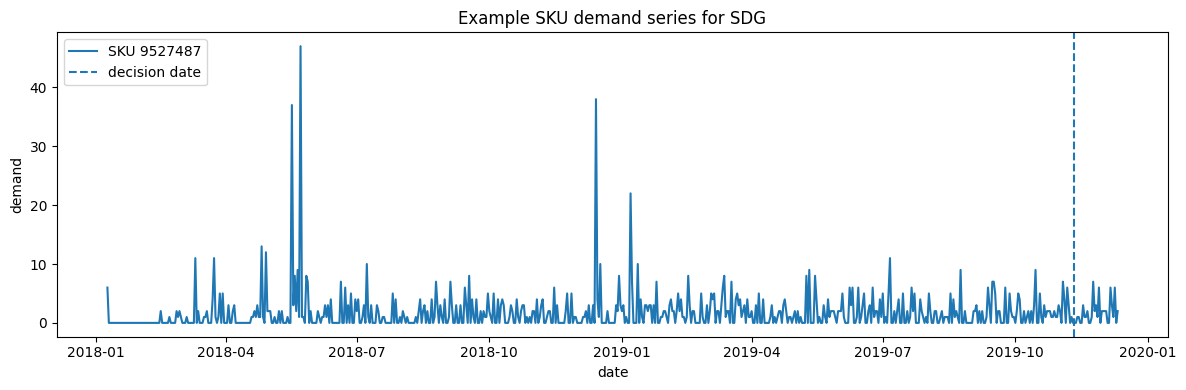

In [5]:
# Case-study helpers
def build_case_payload(sku_df):
    """Build the context/future payload for the case SKU."""
    case_sku = str(sku_df[SKU_COL].iloc[0])
    sku_df = sku_df.sort_values(TIME_COL).reset_index(drop=True)

    decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=PREDICTION_LENGTH)
    train_df = sku_df[sku_df[TIME_COL] <= decision_date].copy()
    test_df = sku_df[sku_df[TIME_COL] > decision_date].copy()

    if len(train_df) < CONTEXT_LENGTH:
        raise ValueError(f"Case SKU {case_sku} has insufficient history: {len(train_df)} < {CONTEXT_LENGTH}")
    if len(test_df) < PREDICTION_LENGTH:
        raise ValueError(f"Case SKU {case_sku} has insufficient future horizon: {len(test_df)} < {PREDICTION_LENGTH}")

    return {
        "sku": case_sku,
        "decision_date": decision_date,
        "train_df": train_df,
        "test_df": test_df,
        "context_values": train_df[DEMAND_COL].astype(float).values[-CONTEXT_LENGTH:],
        "future_values": test_df[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH],
        "real_future": test_df[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH],
        "context_dates": train_df[TIME_COL].iloc[-CONTEXT_LENGTH:].tolist(),
        "future_dates": test_df[TIME_COL].iloc[:PREDICTION_LENGTH].tolist(),
    }

case_df = make_daily_series(panel, str(CASE_SKU), SKU_COL, TIME_COL, PRICE_COL, DEMAND_COL)
case_payload = build_case_payload(case_df)
case_train = case_payload["train_df"]
case_test = case_payload["test_df"]
DECISION_DATE = case_payload["decision_date"]

plt.figure(figsize=(12, 4))
plt.plot(case_df[TIME_COL], case_df[DEMAND_COL], label=f"SKU {CASE_SKU}")
plt.axvline(DECISION_DATE, linestyle="--", label="decision date")
plt.title("Example SKU demand series for SDG")
plt.xlabel("date")
plt.ylabel("demand")
plt.legend()
plt.tight_layout()
plt.show()

## 6) Synthetic future generation

Multiple futures are sampled from the saved SDG model and the best candidate is selected with the notebook scoring rule.

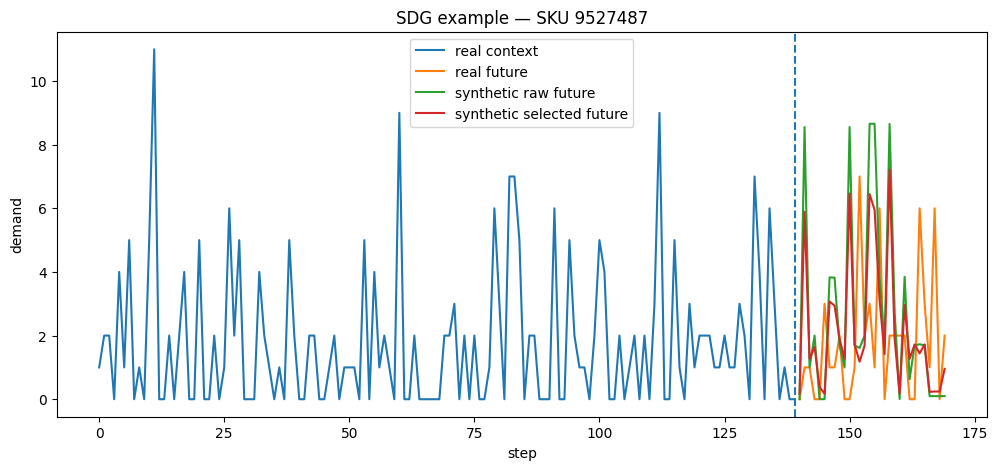

,candidate_index,score
0,3,1.461123
1,17,1.588577
2,11,1.702029
3,7,1.726152
4,39,1.758708
5,45,1.760345
6,30,1.772132
7,46,1.802818
8,37,1.813968
9,2,1.815562


In [6]:
if MODEL_READY:
    context_values = case_payload["context_values"]
    context_dates = case_payload["context_dates"]
    future_dates = case_payload["future_dates"]
    real_future = case_payload.get("real_future", case_payload["future_values"])

    gen_out = generate_proposed_sdg(
        context_values=context_values,
        context_dates=context_dates,
        future_dates=future_dates,
        horizon=PREDICTION_LENGTH,
        metadata=None,
    )

    best_future = np.asarray(gen_out["best_future"], dtype=float)
    best_raw_future = np.asarray(gen_out.get("best_raw_future", gen_out["best_future"]), dtype=float)

    x_context = np.arange(len(context_values))
    x_future = np.arange(len(context_values), len(context_values) + len(real_future))

    plt.figure(figsize=(12, 5))
    plt.plot(x_context, context_values, label="real context")
    plt.plot(x_future, real_future, label="real future")
    plt.plot(x_future, best_raw_future, label="synthetic raw future")
    plt.plot(x_future, best_future, label="synthetic selected future")
    plt.axvline(len(context_values) - 1, linestyle="--")
    plt.title(f"SDG example — SKU {CASE_SKU}")
    plt.xlabel("step")
    plt.ylabel("demand")
    plt.legend()
    plt.show()

    candidate_df = pd.DataFrame(
        {
            "candidate_index": list(range(len(gen_out.get("candidate_scores", [])))),
            "score": gen_out.get("candidate_scores", []),
        }
    ).sort_values("score").reset_index(drop=True)
    display(candidate_df.head(10))

    if "privacy_reference_stats" in gen_out:
        print("Generation privacy reference stats:")
        print(json.dumps(gen_out["privacy_reference_stats"], indent=2))
else:
    print("Model is not ready. Set train-sdg notebook first.")

## 7) Multi-SKU evaluation

The saved model is evaluated on the test SKUs using time-based holdouts.

Evaluated test SKUs: 60


,sku,mae,rmse,candidate_score
0,1132763,0.033440,0.182574,309.153503
1,1116821,1.394434,1.808137,2.833634
2,1023720,1.143594,1.836859,4.323834
3,865178,1.452383,1.970018,2.071694
4,1076056,1.425525,2.037678,1.639933
5,1122358,1.555657,2.210646,1.138194
6,1012873,1.602820,2.238462,2.991595
7,1049788,1.693959,2.296821,1.352420
8,1043590,2.090996,2.531543,1.127149
9,871756,1.739455,2.581607,1.585896


{
  "real_summary": {
    "mean": 553.3283333333334,
    "std": 4418.957920580811,
    "median": 2.0,
    "zero_share": 0.24944444444444444,
    "lag1_acf": 0.7103901783946225,
    "lag7_acf": 0.5611219105180842
  },
  "synthetic_summary": {
    "mean": 635.9619926499321,
    "std": 5493.500757298876,
    "median": 2.659308223948141,
    "zero_share": 0.085,
    "lag1_acf": 0.6639524410807153,
    "lag7_acf": 0.4792809978426948
  },
  "wasserstein_distance": 209.86640236670692,
  "avg_cosine_similarity": 0.5589917929769814,
  "avg_jensen_shannon_distance": 0.5716376872535982,
  "tstr": {
    "mae": 4.0315499941484,
    "rmse": 6.309680529509146
  },
  "trts": {
    "mae": 3.966322698947646,
    "rmse": 6.181798644615462
  },
  "detection_auc": 0.6018518518518519,
  "privacy_proxy": {
    "syn_to_real_mean_min_dist": 3446.63696244325,
    "real_to_real_mean_min_dist": 3436.979428574174,
    "nn_distance_ratio": 1.0028098899250852,
    "share_below_real_p10": 0.1
  },
  "generation_kwarg

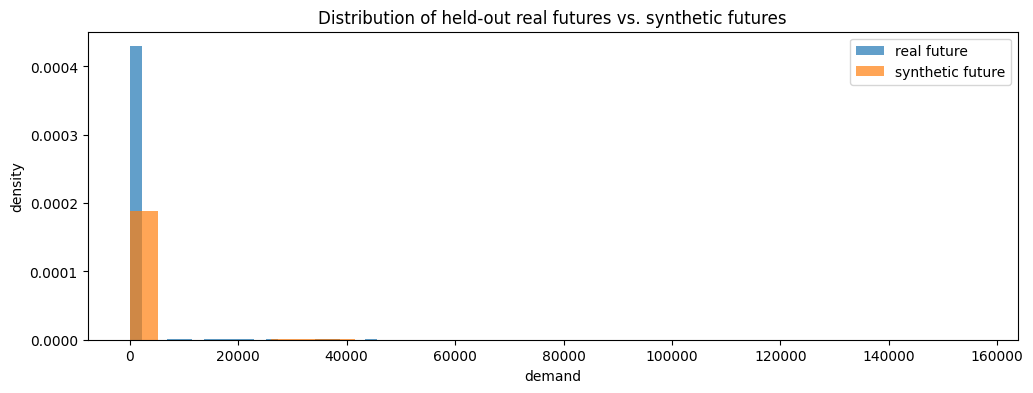

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import wasserstein_distance
from sklearn.metrics.pairwise import cosine_similarity

if MODEL_READY:
    eval_skus = list(TEST_SKUs)
    if MAX_EVAL_TEST_SKUS is not None:
        eval_skus = eval_skus[:int(MAX_EVAL_TEST_SKUS)]

    real_windows = []
    syn_windows = []
    rows = []

    for sku in eval_skus:
        sku_df = make_daily_series(panel, sku, SKU_COL, TIME_COL, PRICE_COL, DEMAND_COL)
        sku_payload = build_case_payload(sku_df)
        sku_train = sku_payload["train_df"]
        sku_test = sku_payload["test_df"]

        if len(sku_train) < CONTEXT_LENGTH or len(sku_test) < PREDICTION_LENGTH:
            continue

        out = generate_proposed_sdg(
            context_values=sku_payload["context_values"],
            context_dates=sku_payload["context_dates"],
            future_dates=sku_payload["future_dates"],
            horizon=PREDICTION_LENGTH,
            metadata=None,
        )
        syn_future = np.asarray(out["best_future"], dtype=float)
        real_future = sku_payload.get("real_future", sku_payload["future_values"])

        real_windows.append(real_future)
        syn_windows.append(syn_future)

        candidate_scores = out.get("candidate_scores", None)
        candidate_score = (
            float(candidate_scores[out["best_index"]])
            if candidate_scores is not None and len(candidate_scores) > 0
            else np.nan
        )

        rows.append(
            {
                "sku": str(sku),
                "mae": float(mean_absolute_error(real_future, syn_future)),
                "rmse": float(np.sqrt(mean_squared_error(real_future, syn_future))),
                "candidate_score": candidate_score,
            }
        )

    eval_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    print("Evaluated test SKUs:", len(eval_df))
    display(eval_df.head(20))

    real_arr = np.asarray(real_windows, dtype=float)
    syn_arr = np.asarray(syn_windows, dtype=float)

    metrics = {
        "real_summary": summarize_windows(real_arr),
        "synthetic_summary": summarize_windows(syn_arr),
        "wasserstein_distance": float(wasserstein_distance(real_arr.ravel(), syn_arr.ravel())),
        "avg_cosine_similarity": float(
            np.mean(
                [
                    cosine_similarity(r.reshape(1, -1), s.reshape(1, -1))[0, 0]
                    for r, s in zip(real_arr, syn_arr)
                ]
            )
        ),
        "avg_jensen_shannon_distance": float(np.mean([js_distance_from_hist(r, s) for r, s in zip(real_arr, syn_arr)])),
    }
    metrics.update(tstr_trts_metrics(real_arr, syn_arr))
    metrics["detection_auc"] = detection_auc(real_arr, syn_arr)
    metrics["privacy_proxy"] = privacy_proxy(real_arr, syn_arr)
    metrics["generation_kwargs"] = dict(PROPOSED_SDG_GENERATION_KWARGS)

    print(json.dumps(metrics, indent=2))

    plt.figure(figsize=(12, 4))
    plt.hist(real_arr.ravel(), bins=30, alpha=0.7, density=True, label="real future")
    plt.hist(syn_arr.ravel(), bins=30, alpha=0.7, density=True, label="synthetic future")
    plt.title("Distribution of held-out real futures vs. synthetic futures")
    plt.xlabel("demand")
    plt.ylabel("density")
    plt.legend()
    plt.show()

    eval_df.to_csv(OUT_DIR / "sdg_eval_per_sku.csv", index=False)
    (OUT_DIR / "sdg_eval_summary.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
else:
    print("Model is not ready. Aggregate evaluation skipped.")

## 8) Benchmark comparison models: GAN, TimeGAN, DGAN, LSTM

In [9]:
from src.dgan import DGANGenerator
from src.gan import GANTimeSeriesGenerator
from src.lstm import LSTMForecastGenerator
from src.timegan import TimeGANGenerator

MODEL_DISPLAY_NAMES = {
    "proposed_sdg": "Proposed SDG",
    "gan": "GAN",
    "timegan": "TimeGAN",
    "dgan": "DGAN",
    "lstm": "LSTM",
}

def display_name(raw_name):
    """Return the report-friendly model name."""
    return MODEL_DISPLAY_NAMES.get(str(raw_name), str(raw_name))

RUN_BENCHMARK_COMPARISON = True

GAN_EPOCHS = 30
TIMEGAN_EPOCHS = 30
DGAN_EPOCHS = 30
LSTM_EPOCHS = 30
BENCHMARK_SEED = 42
BENCHMARK_TRAIN_STRIDE = 7
BENCHMARK_MAX_WINDOWS_PER_TRAIN_SKU = None
BENCHMARK_MAX_EVAL_TEST_SKUS = None
BENCHMARK_BATCH_SIZE = 64
BENCHMARK_HIDDEN_DIM = 64

BENCHMARK_MODEL_CACHE_DIR = OUT_DIR / "benchmark_model_cache"
BENCHMARK_MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_BENCHMARK_COMPARISON:", RUN_BENCHMARK_COMPARISON)
print("BENCHMARK_MODEL_CACHE_DIR:", BENCHMARK_MODEL_CACHE_DIR)

RUN_BENCHMARK_COMPARISON: True
BENCHMARK_MODEL_CACHE_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation/benchmark_model_cache


## 9) Build shared benchmark datasets

In [10]:
if RUN_BENCHMARK_COMPARISON:
    X_train_bench, Y_train_bench, benchmark_train_meta = build_train_windows(
        panel_df=panel,
        skus=TRAIN_SKUs,
        sku_col=SKU_COL,
        time_col=TIME_COL,
        price_col=PRICE_COL,
        demand_col=DEMAND_COL,
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
        stride=BENCHMARK_TRAIN_STRIDE,
        max_windows_per_sku=BENCHMARK_MAX_WINDOWS_PER_TRAIN_SKU,
    )
    eval_skus_bench = list(TEST_SKUs)
    if BENCHMARK_MAX_EVAL_TEST_SKUS is not None:
        eval_skus_bench = eval_skus_bench[:int(BENCHMARK_MAX_EVAL_TEST_SKUS)]
    benchmark_eval_cases = build_eval_cases(
        panel_df=panel,
        skus=eval_skus_bench,
        sku_col=SKU_COL,
        time_col=TIME_COL,
        price_col=PRICE_COL,
        demand_col=DEMAND_COL,
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
    )

    print("Benchmark train windows:", X_train_bench.shape, Y_train_bench.shape)
    print("Benchmark eval cases:", len(benchmark_eval_cases))
    display(benchmark_train_meta.head())
else:
    X_train_bench = np.empty((0, CONTEXT_LENGTH))
    Y_train_bench = np.empty((0, PREDICTION_LENGTH))
    benchmark_eval_cases = []

Benchmark train windows: (18330, 140) (18330, 30)
Benchmark eval cases: 60


,sku,context_start,context_end,future_end
0,1044078,0,140,170
1,1044078,7,147,177
2,1044078,14,154,184
3,1044078,21,161,191
4,1044078,28,168,198


## 10) Train comparison models

In [11]:
benchmark_models = {}
benchmark_results = {}

def _benchmark_cache_key():
    payload = {
        "context_length": int(CONTEXT_LENGTH),
        "horizon": int(PREDICTION_LENGTH),
        "seed": int(BENCHMARK_SEED),
        "batch_size": int(BENCHMARK_BATCH_SIZE),
        "hidden_dim": int(BENCHMARK_HIDDEN_DIM),
        "gan_epochs": int(GAN_EPOCHS),
        "timegan_epochs": int(TIMEGAN_EPOCHS),
        "dgan_epochs": int(DGAN_EPOCHS),
        "lstm_epochs": int(LSTM_EPOCHS),
        "n_train_windows": int(len(X_train_bench)),
        "n_eval_cases": int(len(benchmark_eval_cases)) if 'benchmark_eval_cases' in globals() else 0,
        "train_stride": int(BENCHMARK_TRAIN_STRIDE),
        "max_windows_per_train_sku": BENCHMARK_MAX_WINDOWS_PER_TRAIN_SKU,
        "max_eval_test_skus": BENCHMARK_MAX_EVAL_TEST_SKUS,
    }
    return hashlib.md5(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]

def _benchmark_cache_path(model_name: str) -> Path:
    return BENCHMARK_MODEL_CACHE_DIR / f"{model_name}_{_benchmark_cache_key()}.pt"

def _save_benchmark_model(model_name: str, model_obj):
    import torch

    base_payload = {
        "model_name": model_name,
        "class_name": type(model_obj).__name__,
        "config": {
            "context_length": int(model_obj.context_length),
            "horizon": int(model_obj.horizon),
            "hidden_dim": int(getattr(model_obj, "hidden_dim", BENCHMARK_HIDDEN_DIM)),
            "batch_size": int(getattr(model_obj, "batch_size", BENCHMARK_BATCH_SIZE)),
            "epochs": int(getattr(model_obj, "epochs", 0)),
            "seed": int(getattr(model_obj, "seed", BENCHMARK_SEED)),
            "lr": float(getattr(model_obj, "lr", 1e-3)),
            "device": "cpu",
        },
        "value_mean": float(getattr(model_obj, "value_mean", 0.0)),
        "value_std": float(getattr(model_obj, "value_std", 1.0)),
    }

    if model_name == "gan":
        base_payload["config"]["noise_dim"] = int(getattr(model_obj, "noise_dim", 16))
        base_payload["generator_state_dict"] = {k: v.detach().cpu() for k, v in model_obj.generator.state_dict().items()}
        base_payload["discriminator_state_dict"] = {k: v.detach().cpu() for k, v in model_obj.discriminator.state_dict().items()}
    elif model_name == "timegan":
        base_payload["model_state_dict"] = {k: v.detach().cpu() for k, v in model_obj.model.state_dict().items()}
    elif model_name == "dgan":
        base_payload["config"]["latent_dim"] = int(getattr(model_obj, "latent_dim", 16))
        base_payload["encoder_state_dict"] = {k: v.detach().cpu() for k, v in model_obj.encoder.state_dict().items()}
        base_payload["decoder_state_dict"] = {k: v.detach().cpu() for k, v in model_obj.decoder.state_dict().items()}
    elif model_name == "lstm":
        base_payload["config"]["num_layers"] = int(getattr(model_obj, "num_layers", 1))
        base_payload["model_state_dict"] = {k: v.detach().cpu() for k, v in model_obj.model.state_dict().items()}
    else:
        raise ValueError(f"Unsupported benchmark model: {model_name}")

    cache_path = _benchmark_cache_path(model_name)
    torch.save(base_payload, cache_path)
    print(f"Saved {model_name} benchmark model to: {cache_path}")

def _load_benchmark_model(model_name: str):
    import torch

    cache_path = _benchmark_cache_path(model_name)
    if not cache_path.exists():
        return None

    payload = torch.load(cache_path, map_location="cpu")
    cfg = dict(payload.get("config", {}))
    cfg["device"] = "cpu"

    if model_name == "gan":
        model_obj = GANTimeSeriesGenerator(**cfg)
        model_obj.generator.load_state_dict(payload["generator_state_dict"])
        model_obj.discriminator.load_state_dict(payload["discriminator_state_dict"])
    elif model_name == "timegan":
        model_obj = TimeGANGenerator(**cfg)
        model_obj.model.load_state_dict(payload["model_state_dict"])
    elif model_name == "dgan":
        model_obj = DGANGenerator(**cfg)
        model_obj.encoder.load_state_dict(payload["encoder_state_dict"])
        model_obj.decoder.load_state_dict(payload["decoder_state_dict"])
    elif model_name == "lstm":
        model_obj = LSTMForecastGenerator(**cfg)
        model_obj.model.load_state_dict(payload["model_state_dict"])
    else:
        raise ValueError(f"Unsupported benchmark model: {model_name}")

    model_obj.value_mean = float(payload.get("value_mean", 0.0))
    model_obj.value_std = float(payload.get("value_std", 1.0))
    print(f"Loaded cached {model_name} benchmark model from: {cache_path}")
    return model_obj

def _load_or_train_benchmark_model(model_name: str, builder):
    try:
        cached = _load_benchmark_model(model_name)
        if cached is not None:
            return cached
    except Exception as exc:
        print(f"Failed to load cached {model_name} benchmark model; retraining instead. Reason: {exc}")

    print(f"Training benchmark model: {model_name}")
    model_obj = builder().fit(X_train_bench, Y_train_bench, verbose=True)
    try:
        _save_benchmark_model(model_name, model_obj)
    except Exception as exc:
        print(f"Warning: failed to save {model_name} benchmark model cache. Reason: {exc}")
    return model_obj

if RUN_BENCHMARK_COMPARISON:
    benchmark_models["gan"] = _load_or_train_benchmark_model(
        "gan",
        lambda: GANTimeSeriesGenerator(
            context_length=CONTEXT_LENGTH,
            horizon=PREDICTION_LENGTH,
            hidden_dim=BENCHMARK_HIDDEN_DIM,
            batch_size=BENCHMARK_BATCH_SIZE,
            epochs=GAN_EPOCHS,
            seed=BENCHMARK_SEED,
        ),
    )

    benchmark_models["timegan"] = _load_or_train_benchmark_model(
        "timegan",
        lambda: TimeGANGenerator(
            context_length=CONTEXT_LENGTH,
            horizon=PREDICTION_LENGTH,
            hidden_dim=BENCHMARK_HIDDEN_DIM,
            batch_size=BENCHMARK_BATCH_SIZE,
            epochs=TIMEGAN_EPOCHS,
            seed=BENCHMARK_SEED,
        ),
    )

    benchmark_models["dgan"] = _load_or_train_benchmark_model(
        "dgan",
        lambda: DGANGenerator(
            context_length=CONTEXT_LENGTH,
            horizon=PREDICTION_LENGTH,
            hidden_dim=max(96, BENCHMARK_HIDDEN_DIM),
            batch_size=BENCHMARK_BATCH_SIZE,
            epochs=DGAN_EPOCHS,
            seed=BENCHMARK_SEED,
        ),
    )

    benchmark_models["lstm"] = _load_or_train_benchmark_model(
        "lstm",
        lambda: LSTMForecastGenerator(
            context_length=CONTEXT_LENGTH,
            horizon=PREDICTION_LENGTH,
            hidden_dim=BENCHMARK_HIDDEN_DIM,
            batch_size=BENCHMARK_BATCH_SIZE,
            epochs=LSTM_EPOCHS,
            seed=BENCHMARK_SEED,
        ),
    )

    print("Prepared benchmark models:", list(benchmark_models))
else:
    print("Benchmark comparison disabled.")

Loaded cached gan benchmark model from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation/benchmark_model_cache/gan_686b3bfdee16.pt
Loaded cached timegan benchmark model from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation/benchmark_model_cache/timegan_686b3bfdee16.pt
Loaded cached dgan benchmark model from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation/benchmark_model_cache/dgan_686b3bfdee16.pt
Loaded cached lstm benchmark model from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation/benchmark_model_cache/lstm_686b3bfdee16.pt
Prepared benchmark models: ['gan', 'timegan', 'dgan', 'lstm']


## 11) Evaluate benchmark models on the same held-out SKU futures

In [ ]:
if RUN_BENCHMARK_COMPARISON:
    # Proposed SDG result from existing cells
    if MODEL_READY and 'eval_df' in globals() and 'metrics' in globals():
        benchmark_results["proposed_sdg"] = {
            "per_sku": eval_df.copy(),
            "real_arr": real_arr.copy(),
            "syn_arr": syn_arr.copy(),
            "metrics": dict(metrics),
        }
    else:
        print("Proposed SDG evaluation is not available. Benchmark table will contain only baseline models.")

    for model_name, model_obj in benchmark_models.items():
        per_sku_df, real_model_arr, syn_model_arr, model_metrics = evaluate_generator_on_cases(
            model=model_obj,
            eval_cases=benchmark_eval_cases,
            model_name=model_name,
        )
        benchmark_results[model_name] = {
            "per_sku": per_sku_df,
            "real_arr": real_model_arr,
            "syn_arr": syn_model_arr,
            "metrics": model_metrics,
        }
        print(f"{model_name}: evaluated {len(per_sku_df)} SKUs")
        display(per_sku_df.head())

    benchmark_summary = comparison_summary_table(benchmark_results)
    display(benchmark_summary)
    benchmark_summary.to_csv(OUT_DIR / "sdg_compare_summary.csv", index=False)

    metrics_json = {}
    for name, payload in benchmark_results.items():
        serializable = dict(payload["metrics"])
        serializable.pop("case_predictions", None)
        metrics_json[name] = serializable
    (OUT_DIR / "sdg_compare_metrics.json").write_text(json.dumps(metrics_json, indent=2), encoding="utf-8")
else:
    print("Benchmark comparison disabled.")

gan: evaluated 60 SKUs


,model,sku,mae,rmse
0,gan,5582789,128.753654,230.655502
1,gan,1132763,128.586987,231.562343
2,gan,903325,126.986987,228.496148
3,gan,9527487,128.386987,230.147273
4,gan,880150,127.753654,229.757348


timegan: evaluated 60 SKUs


,model,sku,mae,rmse
0,timegan,5582789,2.333333,4.412105
1,timegan,1132763,0.033333,0.182574
2,timegan,903325,6.166667,7.162402
3,timegan,9527487,1.833333,2.701851
4,timegan,880150,3.600000,5.092478


dgan: evaluated 60 SKUs


,model,sku,mae,rmse
0,dgan,5582789,30.468840,56.839216
1,dgan,1132763,29.310356,57.051421
2,dgan,903325,31.842346,56.592618
3,dgan,9527487,28.944458,55.531964
4,dgan,880150,31.172375,56.149051


lstm: evaluated 60 SKUs


,model,sku,mae,rmse
0,lstm,5582789,146.670605,156.788821
1,lstm,1132763,148.589803,158.140353
2,lstm,903325,144.947595,154.891531
3,lstm,9527487,147.563489,157.106292
4,lstm,880150,146.283110,156.006927


,model,mean,std,zero_share,wasserstein_distance,avg_cosine_similarity,avg_jensen_shannon_distance,pearson_corr,tstr_mae,trts_mae,detection_auc,nn_distance_ratio,share_below_real_p10,avg_rmse
0,timegan,480.701059,3181.270440,0.966667,261.429035,0.021527,0.638669,0.863265,7.777778,1.120000,0.891975,11.163521,0.333333,394.081621
1,dgan,733.004612,4804.695238,0.547778,287.406392,0.356728,0.407351,0.858340,7.777778,20.875278,1.000000,0.694985,0.000000,472.153799
2,proposed_sdg,635.961993,5493.500757,0.085000,209.866402,0.558992,0.571638,NaN,4.031550,3.966323,0.601852,1.002810,0.100000,639.650113
3,gan,780.083010,4793.598529,0.386667,341.193682,0.401398,0.491334,0.832011,292.868218,275.090996,1.000000,11.835926,0.000000,661.787373
4,lstm,891.842624,4030.921501,0.000000,621.880124,0.629364,0.826700,0.694844,64.206546,27.536600,1.000000,1.109092,0.000000,758.458789


## 12) Compare feature correlations, value distributions, and one-step differences

Correlation in real held-out futures:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.980563,0.980541,0.980571,0.983811,-0.082139,0.980573,0.980566,0.980570,0.980524,...,0.875171,0.980557,0.980578,0.980569,0.980533,0.959356,0.980497,0.980552,0.996206,0.999873
step_001,0.980563,1.000000,0.999999,0.999999,0.929528,-0.068759,1.000000,0.999999,0.999999,0.999996,...,0.763236,0.999999,0.999999,1.000000,0.999997,0.885342,0.999990,0.999998,0.959769,0.977330
step_002,0.980541,0.999999,1.000000,0.999998,0.929489,-0.067705,0.999998,0.999998,0.999998,0.999997,...,0.763170,0.999998,0.999997,0.999998,0.999997,0.885293,0.999993,0.999999,0.959739,0.977307
step_003,0.980571,0.999999,0.999998,1.000000,0.929543,-0.069151,1.000000,0.999999,1.000000,0.999994,...,0.763263,0.999998,1.000000,0.999999,0.999996,0.885361,0.999988,0.999998,0.959781,0.977338
step_004,0.983811,0.929528,0.929489,0.929543,1.000000,-0.090499,0.929546,0.929534,0.929542,0.929461,...,0.947706,0.929518,0.929556,0.929540,0.929475,0.994397,0.929417,0.929509,0.995674,0.986527
step_005,-0.082139,-0.068759,-0.067705,-0.069151,-0.090499,1.000000,-0.068784,-0.068679,-0.068800,-0.066545,...,-0.098554,-0.068276,-0.069331,-0.068911,-0.067484,-0.094332,-0.065474,-0.067990,-0.086775,-0.082224
step_006,0.980573,1.000000,0.999998,1.000000,0.929546,-0.068784,1.000000,1.000000,1.000000,0.999995,...,0.763269,0.999999,1.000000,1.000000,0.999997,0.885365,0.999990,0.999999,0.959784,0.977340
step_007,0.980566,0.999999,0.999998,0.999999,0.929534,-0.068679,1.000000,1.000000,0.999999,0.999995,...,0.763247,0.999998,0.999999,0.999999,0.999997,0.885350,0.999990,0.999999,0.959774,0.977333
step_008,0.980570,0.999999,0.999998,1.000000,0.929542,-0.068800,1.000000,0.999999,1.000000,0.999995,...,0.763260,0.999999,1.000000,1.000000,0.999997,0.885359,0.999989,0.999998,0.959780,0.977338
step_009,0.980524,0.999996,0.999997,0.999994,0.929461,-0.066545,0.999995,0.999995,0.999995,1.000000,...,0.763125,0.999997,0.999994,0.999996,0.999996,0.885259,0.999995,0.999997,0.959716,0.977291


Correlation in synthetic futures for proposed_sdg:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.999881,0.999823,0.999989,0.885320,0.999999,0.999999,0.999999,0.999999,0.999999,...,0.999745,0.999999,0.999999,0.999821,0.999726,0.893234,0.999999,0.999999,0.999999,0.999999
step_001,0.999881,1.000000,0.999994,0.999939,0.892383,0.999890,0.999881,0.999881,0.999881,0.999879,...,0.999974,0.999881,0.999881,0.999993,0.999968,0.900059,0.999889,0.999882,0.999881,0.999881
step_002,0.999823,0.999994,1.000000,0.999897,0.893894,0.999834,0.999823,0.999823,0.999823,0.999822,...,0.999992,0.999824,0.999824,0.999999,0.999989,0.901518,0.999834,0.999824,0.999824,0.999823
step_003,0.999989,0.999939,0.999897,1.000000,0.887388,0.999992,0.999990,0.999990,0.999990,0.999989,...,0.999837,0.999990,0.999990,0.999896,0.999821,0.895234,0.999992,0.999990,0.999990,0.999989
step_004,0.885320,0.892383,0.893894,0.887388,1.000000,0.885637,0.885335,0.885332,0.885337,0.885304,...,0.895568,0.885339,0.885338,0.893919,0.895951,0.999850,0.885589,0.885351,0.885345,0.885336
step_005,0.999999,0.999890,0.999834,0.999992,0.885637,1.000000,0.999999,0.999999,0.999999,0.999997,...,0.999760,0.999999,0.999999,0.999833,0.999741,0.893540,0.999999,0.999999,0.999999,0.999999
step_006,0.999999,0.999881,0.999823,0.999990,0.885335,0.999999,1.000000,0.999999,1.000000,0.999999,...,0.999746,1.000000,1.000000,0.999822,0.999727,0.893249,1.000000,1.000000,1.000000,0.999999
step_007,0.999999,0.999881,0.999823,0.999990,0.885332,0.999999,0.999999,1.000000,0.999999,0.999999,...,0.999746,1.000000,1.000000,0.999822,0.999727,0.893246,0.999999,1.000000,1.000000,0.999999
step_008,0.999999,0.999881,0.999823,0.999990,0.885337,0.999999,1.000000,0.999999,1.000000,0.999999,...,0.999747,1.000000,1.000000,0.999822,0.999727,0.893250,1.000000,1.000000,1.000000,0.999999
step_009,0.999999,0.999879,0.999822,0.999989,0.885304,0.999997,0.999999,0.999999,0.999999,1.000000,...,0.999745,0.999999,0.999999,0.999821,0.999725,0.893219,0.999999,0.999999,0.999999,0.999998


Correlation in synthetic futures for gan:


...

,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.999491,0.998044,0.996619,0.996009,0.996023,0.996260,0.996523,0.996759,0.996970,...,0.998981,0.999125,0.999258,0.999379,0.999490,0.999589,0.999677,0.999754,0.999820,0.999875
step_001,0.999491,1.000000,0.999530,0.998733,0.998350,0.998358,0.998510,0.998674,0.998818,0.998944,...,0.999913,0.999951,0.999978,0.999994,1.000000,0.999995,0.999979,0.999953,0.999916,0.999870
step_002,0.998044,0.999530,1.000000,0.999806,0.999641,0.999645,0.999713,0.999782,0.999838,0.999883,...,0.999848,0.999785,0.999712,0.999627,0.999531,0.999426,0.999310,0.999185,0.999050,0.998908
step_003,0.996619,0.998733,0.999806,1.000000,0.999975,0.999976,0.999991,0.999999,0.999999,0.999990,...,0.999311,0.999183,0.999044,0.998894,0.998734,0.998564,0.998384,0.998195,0.997998,0.997793
step_004,0.996009,0.998350,0.999641,0.999975,1.000000,1.000000,0.999996,0.999982,0.999961,0.999934,...,0.999022,0.998871,0.998708,0.998535,0.998351,0.998158,0.997955,0.997743,0.997523,0.997296
step_005,0.996023,0.998358,0.999645,0.999976,1.000000,1.000000,0.999996,0.999983,0.999962,0.999936,...,0.999029,0.998878,0.998716,0.998543,0.998360,0.998167,0.997964,0.997753,0.997534,0.997307
step_006,0.996260,0.998510,0.999713,0.999991,0.999996,0.999996,1.000000,0.999995,0.999982,0.999963,...,0.999144,0.999002,0.998849,0.998685,0.998511,0.998327,0.998133,0.997931,0.997720,0.997501
step_007,0.996523,0.998674,0.999782,0.999999,0.999982,0.999983,0.999995,1.000000,0.999996,0.999985,...,0.999268,0.999136,0.998993,0.998839,0.998675,0.998501,0.998318,0.998125,0.997924,0.997716
step_008,0.996759,0.998818,0.999838,0.999999,0.999961,0.999962,0.999982,0.999996,1.000000,0.999996,...,0.999374,0.999252,0.999118,0.998974,0.998820,0.998655,0.998481,0.998298,0.998106,0.997906
step_009,0.996970,0.998944,0.999883,0.999990,0.999934,0.999936,0.999963,0.999985,0.999996,1.000000,...,0.999465,0.999351,0.999227,0.999091,0.998946,0.998790,0.998624,0.998450,0.998266,0.998075


Correlation in synthetic futures for dgan:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.999450,0.999781,0.999922,0.999225,0.999483,0.999658,0.999990,0.995970,0.999876,...,0.999613,0.999859,0.999248,0.999838,0.999981,0.992867,0.999761,0.999675,0.999450,0.999383
step_001,0.999450,1.000000,0.998537,0.998959,0.999979,0.997868,0.999975,0.999590,0.998397,0.999848,...,0.999986,0.998751,0.999984,0.998695,0.999227,0.996276,0.998494,0.999968,0.997799,0.999998
step_002,0.999781,0.998537,1.000000,0.999964,0.998186,0.999937,0.998893,0.999675,0.993876,0.999327,...,0.998813,0.999991,0.998219,0.999995,0.999891,0.990156,0.999996,0.998926,0.999924,0.998430
step_003,0.999922,0.998959,0.999964,1.000000,0.998659,0.999806,0.999255,0.999855,0.994775,0.999602,...,0.999189,0.999990,0.998688,0.999984,0.999980,0.991305,0.999954,0.999281,0.999785,0.998869
step_004,0.999225,0.999979,0.998186,0.998659,1.000000,0.997451,0.999911,0.999394,0.998722,0.999720,...,0.999932,0.998424,0.999999,0.998364,0.998966,0.996782,0.998145,0.999904,0.997372,0.999989
step_005,0.999483,0.997868,0.999937,0.999806,0.997451,1.000000,0.998303,0.999327,0.992575,0.998853,...,0.998204,0.999882,0.997488,0.999899,0.999662,0.988525,0.999943,0.998345,0.999998,0.997740
step_006,0.999658,0.999975,0.998893,0.999255,0.999911,0.998303,1.000000,0.999767,0.997974,0.999946,...,0.999999,0.999078,0.999920,0.999029,0.999479,0.995644,0.998855,0.999998,0.998241,0.999960
step_007,0.999990,0.999590,0.999675,0.999855,0.999394,0.999327,0.999767,1.000000,0.996367,0.999937,...,0.999729,0.999772,0.999414,0.999747,0.999943,0.993399,0.999653,0.999780,0.999288,0.999533
step_008,0.995970,0.998397,0.993876,0.994775,0.998722,0.992575,0.997974,0.996367,1.000000,0.997259,...,0.998079,0.994322,0.998698,0.994204,0.995400,0.999559,0.993794,0.997926,0.992446,0.998505
step_009,0.999876,0.999848,0.999327,0.999602,0.999720,0.998853,0.999946,0.999937,0.997259,1.000000,...,0.999927,0.999470,0.999734,0.999433,0.999760,0.994622,0.999297,0.999951,0.998803,0.999812


Correlation in synthetic futures for lstm:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.999873,0.999927,0.999918,0.999052,0.999603,0.999229,0.999994,0.999979,0.999993,...,0.999529,0.999934,0.999863,0.999990,0.999525,0.999275,0.999859,0.999135,0.999928,0.999789
step_001,0.999873,1.000000,0.999992,0.999995,0.999618,0.999925,0.999727,0.999810,0.999956,0.999927,...,0.999890,0.999990,1.000000,0.999933,0.999889,0.999754,1.000000,0.999670,0.999992,0.999989
step_002,0.999927,0.999992,1.000000,1.000000,0.999504,0.999870,0.999629,0.999878,0.999985,0.999966,...,0.999826,1.000000,0.999990,0.999971,0.999824,0.999661,0.999989,0.999563,1.000000,0.999964
step_003,0.999918,0.999995,1.000000,1.000000,0.999527,0.999881,0.999650,0.999866,0.999980,0.999960,...,0.999840,0.999999,0.999993,0.999965,0.999837,0.999680,0.999992,0.999585,1.000000,0.999970
step_004,0.999052,0.999618,0.999504,0.999527,1.000000,0.999882,0.999991,0.998891,0.999316,0.999211,...,0.999917,0.999485,0.999635,0.999233,0.999919,0.999985,0.999641,0.999998,0.999502,0.999735
step_005,0.999603,0.999925,0.999870,0.999881,0.999882,1.000000,0.999939,0.999496,0.999766,0.999703,...,0.999997,0.999860,0.999932,0.999717,0.999996,0.999951,0.999935,0.999910,0.999869,0.999970
step_006,0.999229,0.999727,0.999629,0.999650,0.999991,0.999939,1.000000,0.999083,0.999465,0.999371,...,0.999963,0.999614,0.999742,0.999392,0.999964,0.999999,0.999747,0.999997,0.999628,0.999824
step_007,0.999994,0.999810,0.999878,0.999866,0.998891,0.999496,0.999083,1.000000,0.999949,0.999973,...,0.999413,0.999887,0.999798,0.999968,0.999409,0.999133,0.999793,0.998981,0.999879,0.999710
step_008,0.999979,0.999956,0.999985,0.999980,0.999316,0.999766,0.999465,0.999949,1.000000,0.999996,...,0.999708,0.999988,0.999950,0.999998,0.999705,0.999503,0.999948,0.999386,0.999985,0.999902
step_009,0.999993,0.999927,0.999966,0.999960,0.999211,0.999703,0.999371,0.999973,0.999996,1.000000,...,0.999638,0.999971,0.999919,1.000000,0.999635,0.999413,0.999916,0.999286,0.999967,0.999860


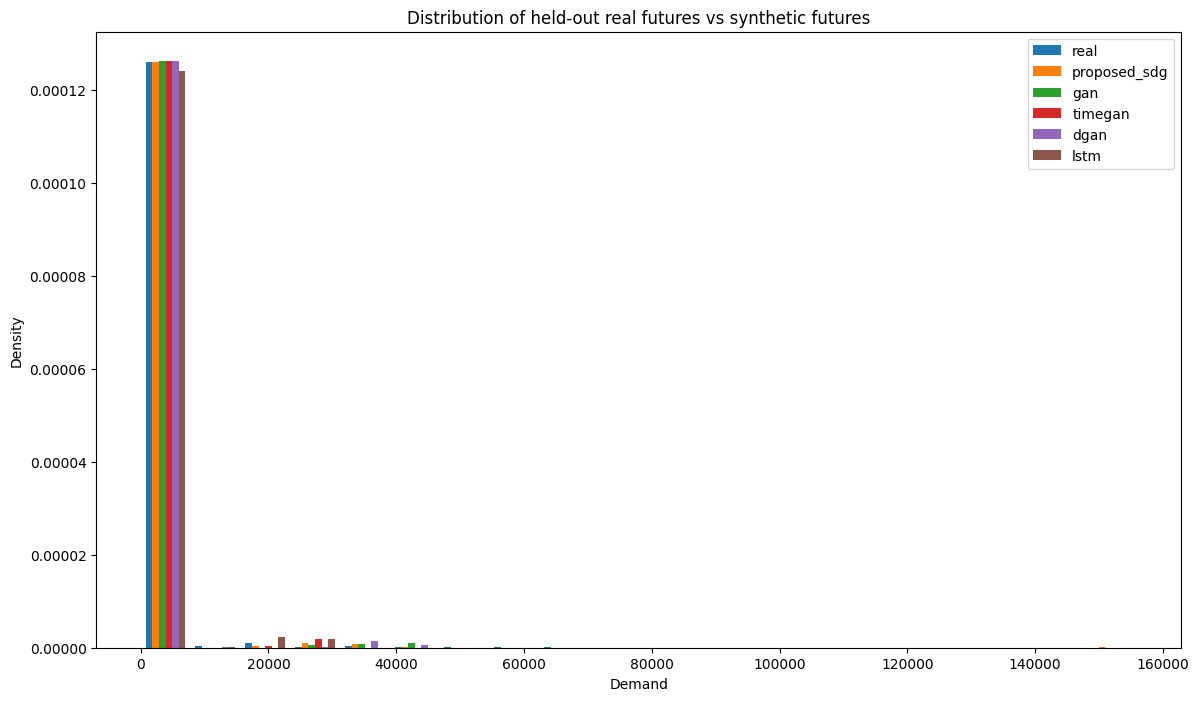

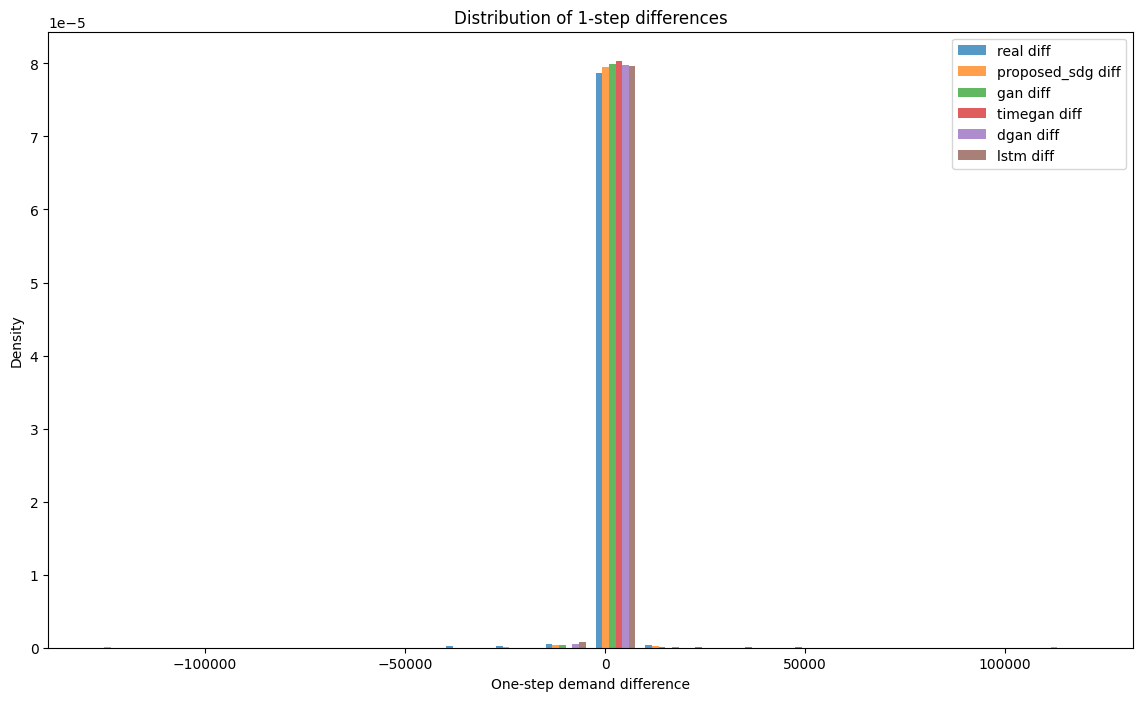

In [13]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    real_reference = None
    for payload in benchmark_results.values():
        if payload["real_arr"].size:
            real_reference = payload["real_arr"]
            break

    if real_reference is not None:
        real_df_features = windows_to_feature_dataframe(real_reference, prefix="step")
        print("Correlation in real held-out futures:")
        display(real_df_features.corr())

        for name, payload in benchmark_results.items():
            syn_df_features = windows_to_feature_dataframe(payload["syn_arr"], prefix="step")
            print(f"Correlation in synthetic futures for {name}:")
            display(syn_df_features.corr())

        plt.figure(figsize=(14, 8))
        hist_values = [real_reference.ravel()]
        hist_labels = ["real"]
        for name, payload in benchmark_results.items():
            hist_values.append(payload["syn_arr"].ravel())
            hist_labels.append(name)
        plt.hist(hist_values, label=hist_labels, bins=20, density=True)
        plt.legend()
        plt.xlabel("Demand")
        plt.ylabel("Density")
        plt.title("Distribution of held-out real futures vs synthetic futures")
        plt.show()

        plt.figure(figsize=(14, 8))
        diff_values = [np.diff(real_reference, axis=1).ravel()]
        diff_labels = ["real diff"]
        for name, payload in benchmark_results.items():
            diff_values.append(np.diff(payload["syn_arr"], axis=1).ravel())
            diff_labels.append(f"{name} diff")
        plt.hist(diff_values, label=diff_labels, bins=20, density=True, alpha=0.75)
        plt.legend()
        plt.xlabel("One-step demand difference")
        plt.ylabel("Density")
        plt.title("Distribution of 1-step differences")
        plt.show()
    else:
        print("No benchmark windows available.")

## 13) Similarity statistics and case-SKU comparison plot

,model,avg_cosine_similarity_windowed,avg_jensen_shannon_distance_windowed,pearson_corr_flattened
4,lstm,0.720660,0.355356,0.694844
0,proposed_sdg,0.683593,0.362820,0.667735
1,gan,0.525211,0.520061,0.832011
3,dgan,0.389531,0.624544,0.858340
2,timegan,0.020573,0.916430,0.863265


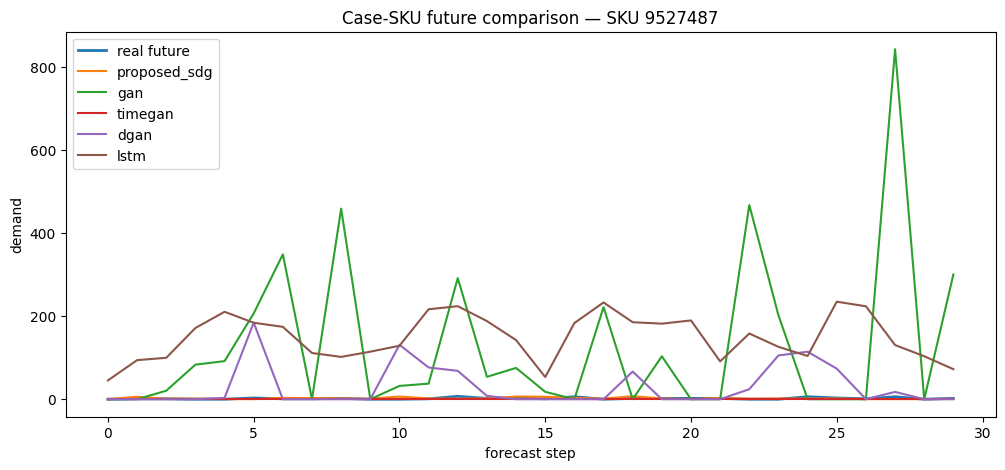

In [14]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    real_reference = None
    for payload in benchmark_results.values():
        if payload["real_arr"].size:
            real_reference = payload["real_arr"]
            break

    if real_reference is not None:
        similarity_rows = []
        for name, payload in benchmark_results.items():
            sim_cos = float(np.mean([
                average_cosine_similarity(r, s, window_size=3, step_size=1)
                for r, s in zip(real_reference, payload["syn_arr"])
            ]))
            sim_js = float(np.mean([
                average_jensen_shannon_distance(r, s, window_size=3, step_size=1)
                for r, s in zip(real_reference, payload["syn_arr"])
            ]))
            pearson_corr = float(np.corrcoef(real_reference.ravel(), payload["syn_arr"].ravel())[0, 1])
            similarity_rows.append({
                "model": name,
                "avg_cosine_similarity_windowed": sim_cos,
                "avg_jensen_shannon_distance_windowed": sim_js,
                "pearson_corr_flattened": pearson_corr,
            })

        similarity_df = pd.DataFrame(similarity_rows).sort_values("avg_cosine_similarity_windowed", ascending=False)
        display(similarity_df)
        similarity_df.to_csv(OUT_DIR / "sdg_compare_similarity.csv", index=False)

        if MODEL_READY:
            case_context_values = np.asarray(case_payload["context_values"], dtype=float)
            case_real_future = np.asarray(case_payload.get("real_future", case_payload["future_values"]), dtype=float)
            case_context_dates = case_payload["context_dates"]
            case_future_dates = case_payload["future_dates"]

            case_predictions = {
                "proposed_sdg": np.asarray(best_future, dtype=float) if 'best_future' in globals() else None
            }
            for name, model_obj in benchmark_models.items():
                case_predictions[name] = np.asarray(
                    model_obj.generate(case_context_values, horizon=PREDICTION_LENGTH),
                    dtype=float,
                )

            plt.figure(figsize=(12, 5))
            plt.plot(case_real_future, label="real future", linewidth=2)
            for name, pred in case_predictions.items():
                if pred is not None:
                    plt.plot(pred, label=name)
            plt.title(f"Case-SKU future comparison — SKU {CASE_SKU}")
            plt.xlabel("forecast step")
            plt.ylabel("demand")
            plt.legend()
            plt.show()
    else:
        print("No benchmark windows available.")

## 14) Evaluation by fidelity, utility, and privacy

The thesis frames the evaluation around three dimensions: *fidelity*, *utility*, and *privacy*.  
The cells below extend the existing DIF-PI SDG validation flow with experiments:
- a context-window sweep,
- a post hoc RNN discriminative score,
- a post hoc RNN predictive score,
- an XGBoost forecasting score,
- a privacy-against-inference block with four attack models,
- and cross-product correlation tables for real and synthetic futures.

All compared baselines are displayed using their direct model names: GAN, TimeGAN, DGAN, and LSTM.

In [ ]:
# Helper functions for benchmark models and evaluation

import warnings
from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import RadiusNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except Exception:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_XGBOOST = False

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

MODEL_DISPLAY_NAMES = {
    "proposed_sdg": "Proposed SDG",
    "gan": "GAN",
    "timegan": "TimeGAN",
    "dgan": "DGAN",
    "lstm": "LSTM",
}

def display_name(name):
    return MODEL_DISPLAY_NAMES.get(str(name), str(name))

def get_real_reference(benchmark_results):
    for payload in benchmark_results.values():
        arr = np.asarray(payload.get("real_arr", np.empty((0, 0))), dtype=float)
        if arr.size:
            return arr
    return np.empty((0, 0))

def final_step_dataset(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return np.empty((0, 0)), np.empty((0,))
    return arr[:, :-1], arr[:, -1]

def privacy_attack_dataset(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 4:
        return np.empty((0, 0)), np.empty((0, 0))
    split = arr.shape[1] // 2
    X = arr[:, :split]
    Y = arr[:, split:]
    return X, Y

def selected_eval_skus(eval_df, max_products=6):
    if 'sku' in eval_df.columns and len(eval_df):
        return list(eval_df['sku'].astype(str).head(max_products))
    return []

def build_case_map(panel_df, skus, context_length, horizon):
    out = {}
    for sku in skus:
        sku_df = make_daily_series(panel_df, sku, SKU_COL, TIME_COL, PRICE_COL, DEMAND_COL)
        decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=horizon)
        sku_train = sku_df[sku_df[TIME_COL] <= decision_date].copy()
        sku_test = sku_df[sku_df[TIME_COL] > decision_date].copy()
        if len(sku_train) < context_length or len(sku_test) < horizon:
            continue
        out[str(sku)] = {
            "train": sku_train,
            "test": sku_test,
            "context_values": sku_train[DEMAND_COL].astype(float).values[-context_length:],
            "context_dates": sku_train[TIME_COL].iloc[-context_length:].tolist(),
            "future_dates": sku_test[TIME_COL].iloc[:horizon].tolist(),
            "real_future": sku_test[DEMAND_COL].astype(float).values[:horizon],
        }
    return out

def model_synthetic_case_predictions(sku_case_map, benchmark_models, proposed_available=True):
    preds = {}
    if proposed_available and MODEL_READY and 'best_future' in globals():
        # case_sku handled separately, not used in generic map
        pass
    for name, model_obj in benchmark_models.items():
        preds[name] = {}
        for sku, payload in sku_case_map.items():
            preds[name][sku] = np.asarray(
                model_obj.generate(payload["context_values"], horizon=PREDICTION_LENGTH),
                dtype=float,
            )
    return preds

if HAS_TORCH:
    class _RNNBinaryClassifier(nn.Module):
        def __init__(self, hidden_dim=32):
            super().__init__()
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
            self.head = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            out, _ = self.rnn(x)
            return self.head(out[:, -1, :]).squeeze(-1)

    class _RNNRegressor(nn.Module):
        def __init__(self, hidden_dim=32):
            super().__init__()
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
            self.head = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            out, _ = self.rnn(x)
            return self.head(out[:, -1, :]).squeeze(-1)

def posthoc_rnn_discriminative_score(real_arr, syn_arr, epochs=12, hidden_dim=32, batch_size=32, seed=42):
    real_arr = np.asarray(real_arr, dtype=float)
    syn_arr = np.asarray(syn_arr, dtype=float)
    if not HAS_TORCH or real_arr.size == 0 or syn_arr.size == 0:
        return {"accuracy": np.nan, "score": np.nan}
    X = np.concatenate([real_arr, syn_arr], axis=0)
    y = np.concatenate([np.ones(len(real_arr)), np.zeros(len(syn_arr))], axis=0)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y
    )

    torch.manual_seed(seed)
    model = _RNNBinaryClassifier(hidden_dim=hidden_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    ds = TensorDataset(
        torch.tensor(X_train[:, :, None], dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=min(batch_size, len(ds)), shuffle=True)

    model.train()
    for _ in range(int(epochs)):
        for xb, yb in dl:
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.inference_mode():
        logits = model(torch.tensor(X_test[:, :, None], dtype=torch.float32))
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

    acc = float(accuracy_score(y_test, preds))
    score = float(abs(acc - 0.5))
    return {"accuracy": acc, "score": score}

def posthoc_rnn_predictive_score(real_arr, syn_arr, epochs=12, hidden_dim=32, batch_size=32, seed=42):
    real_arr = np.asarray(real_arr, dtype=float)
    syn_arr = np.asarray(syn_arr, dtype=float)
    X_syn, y_syn = final_step_dataset(syn_arr)
    X_real, y_real = final_step_dataset(real_arr)
    if not HAS_TORCH or X_syn.size == 0 or X_real.size == 0:
        return {"mae": np.nan, "rmse": np.nan}

    torch.manual_seed(seed)
    model = _RNNRegressor(hidden_dim=hidden_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    ds = TensorDataset(
        torch.tensor(X_syn[:, :, None], dtype=torch.float32),
        torch.tensor(y_syn, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=min(batch_size, len(ds)), shuffle=True)

    model.train()
    for _ in range(int(epochs)):
        for xb, yb in dl:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.inference_mode():
        pred = model(torch.tensor(X_real[:, :, None], dtype=torch.float32)).cpu().numpy()

    return {
        "mae": float(mean_absolute_error(y_real, pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_real, pred))),
    }

def xgboost_forecasting_score(real_arr, syn_arr, seed=42):
    real_arr = np.asarray(real_arr, dtype=float)
    syn_arr = np.asarray(syn_arr, dtype=float)
    X_syn, y_syn = final_step_dataset(syn_arr)
    X_real, y_real = final_step_dataset(real_arr)
    if X_syn.size == 0 or X_real.size == 0:
        return {"mae": np.nan, "rmse": np.nan, "model_family": "xgboost"}

    if HAS_XGBOOST:
        model = xgb.XGBRegressor(
            n_estimators=120,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=seed,
            objective="reg:squarederror",
        )
        family = "xgboost"
    else:
        model = GradientBoostingRegressor(random_state=seed)
        family = "gradient_boosting_fallback"

    model.fit(X_syn, y_syn)
    pred = np.asarray(model.predict(X_real), dtype=float)
    return {
        "mae": float(mean_absolute_error(y_real, pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_real, pred))),
        "model_family": family,
    }

def privacy_inference_block(benchmark_results, seed=42):
    real_ref = get_real_reference(benchmark_results)
    X_real, Y_real = privacy_attack_dataset(real_ref)
    if X_real.size == 0:
        return pd.DataFrame()

    attack_models = {
        "NumericalMLP": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, random_state=seed)),
        ]),
        "NumericalLR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "NumericalSVR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MultiOutputRegressor(SVR(C=1.0, epsilon=0.1, kernel="rbf"))),
        ]),
        "NumericalRadNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RadiusNeighborsRegressor(radius=2.5, weights="distance")),
        ]),
    }

    rows = []
    Xr_tr, Xr_te, Yr_tr, Yr_te = train_test_split(X_real, Y_real, test_size=0.30, random_state=seed)

    for attack_name, attack_model in attack_models.items():
        try:
            attack_model.fit(Xr_tr, Yr_tr)
            pred_real = np.asarray(attack_model.predict(Xr_te), dtype=float)
            rows.append({
                "train_source": "real_train_baseline",
                "attack_model": attack_name,
                "mae": float(mean_absolute_error(Yr_te, pred_real)),
                "rmse": float(np.sqrt(mean_squared_error(Yr_te, pred_real))),
            })
        except Exception as exc:
            rows.append({
                "train_source": "real_train_baseline",
                "attack_model": attack_name,
                "mae": np.nan,
                "rmse": np.nan,
                "error": str(exc),
            })

    for model_name, payload in benchmark_results.items():
        syn_arr = np.asarray(payload.get("syn_arr", np.empty((0, 0))), dtype=float)
        X_syn, Y_syn = privacy_attack_dataset(syn_arr)
        if X_syn.size == 0:
            continue

        for attack_name, attack_model in attack_models.items():
            try:
                attack_model.fit(X_syn, Y_syn)
                pred = np.asarray(attack_model.predict(Xr_te), dtype=float)
                rows.append({
                    "train_source": display_name(model_name),
                    "attack_model": attack_name,
                    "mae": float(mean_absolute_error(Yr_te, pred)),
                    "rmse": float(np.sqrt(mean_squared_error(Yr_te, pred))),
                })
            except Exception as exc:
                rows.append({
                    "train_source": display_name(model_name),
                    "attack_model": attack_name,
                    "mae": np.nan,
                    "rmse": np.nan,
                    "error": str(exc),
                })

    return pd.DataFrame(rows)


def privacy_gain_summary(privacy_df):
    """Aggregate privacy against the held-out real-data baseline."""
    use_df = privacy_df.copy()
    baseline = (
        use_df[use_df["train_source"] == "real_train_baseline"]
        .groupby("attack_model", as_index=False)["mae"]
        .mean()
        .rename(columns={"mae": "baseline_mae"})
    )
    out = (
        use_df[use_df["train_source"] != "real_train_baseline"]
        .groupby(["train_source", "attack_model"], as_index=False)["mae"]
        .mean()
        .merge(baseline, on="attack_model", how="left")
    )
    out["privacy_gain"] = out["mae"] / (out["baseline_mae"] + 1e-8)
    out["privacy_gain_capped"] = out["privacy_gain"].clip(lower=0.0, upper=10.0)
    return out

def correlation_table_for_selected_skus(panel_df, skus, model_name=None, model_obj=None, proposed=False):
    sku_case_map = build_case_map(panel_df, skus, CONTEXT_LENGTH, PREDICTION_LENGTH)
    if not sku_case_map:
        return pd.DataFrame()

    real_matrix = {}
    syn_matrix = {}
    for sku, payload in sku_case_map.items():
        real_matrix[str(sku)] = np.asarray(payload["real_future"], dtype=float)
        if proposed:
            out = generate_proposed_sdg(
                context_values=payload["context_values"],
                context_dates=payload["context_dates"],
                future_dates=payload["future_dates"],
                horizon=PREDICTION_LENGTH,
                metadata=None,
            )
            syn_matrix[str(sku)] = np.asarray(out["best_future"], dtype=float)
        elif model_obj is not None:
            syn_matrix[str(sku)] = np.asarray(
                model_obj.generate(payload["context_values"], horizon=PREDICTION_LENGTH),
                dtype=float,
            )

    real_df = pd.DataFrame(real_matrix)
    syn_df = pd.DataFrame(syn_matrix)
    return real_df.corr(), syn_df.corr()

def build_fidelity_summary(benchmark_results):
    rows = []
    for name, payload in benchmark_results.items():
        metrics_local = dict(payload.get("metrics", {}))
        rows.append({
            "model": display_name(name),
            "wasserstein_distance": metrics_local.get("wasserstein_distance", np.nan),
            "avg_cosine_similarity": metrics_local.get("avg_cosine_similarity", np.nan),
            "avg_jensen_shannon_distance": metrics_local.get("avg_jensen_shannon_distance", np.nan),
            "detection_auc": metrics_local.get("detection_auc", np.nan),
        })
    return pd.DataFrame(rows)

### 14.1 Fidelity

This block collects the *fidelity* diagnostics:
- a compact fidelity summary table,
- a post hoc RNN discriminative score,
- and cross-product correlation tables for selected SKUs.


In [16]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    fidelity_summary_df = build_fidelity_summary(benchmark_results)
    display(fidelity_summary_df.sort_values("avg_cosine_similarity", ascending=False))
    fidelity_summary_df.to_csv(OUT_DIR / "paper_fidelity_summary.csv", index=False)

    real_reference = get_real_reference(benchmark_results)
    discriminative_rows = []
    for name, payload in benchmark_results.items():
        disc = posthoc_rnn_discriminative_score(real_reference, payload["syn_arr"], epochs=12, hidden_dim=32, batch_size=32, seed=BENCHMARK_SEED)
        discriminative_rows.append({
            "model": display_name(name),
            "discriminative_accuracy_rnn": disc.get("accuracy", np.nan),
            "discriminative_score_rnn": disc.get("score", np.nan),
        })
    discriminative_df = pd.DataFrame(discriminative_rows).sort_values("discriminative_score_rnn")
    display(discriminative_df)
    discriminative_df.to_csv(OUT_DIR / "paper_discriminative_score.csv", index=False)

    corr_skus = selected_eval_skus(eval_df if 'eval_df' in globals() else pd.DataFrame(), max_products=6)
    if len(corr_skus) >= 2:
        print("Selected SKUs for cross-product correlation tables:", corr_skus)

        real_corr, proposed_corr = correlation_table_for_selected_skus(
            panel, corr_skus, proposed=True
        )
        print("Real cross-product correlation table:")
        display(real_corr)
        print("Synthetic cross-product correlation table — Proposed SDG")
        display(proposed_corr)
        real_corr.to_csv(OUT_DIR / "paper_corr_real.csv")
        proposed_corr.to_csv(OUT_DIR / "paper_corr_proposed_sdg.csv")

        for model_name, model_obj in benchmark_models.items():
            _, model_corr = correlation_table_for_selected_skus(
                panel, corr_skus, model_name=model_name, model_obj=model_obj, proposed=False
            )
            print(f"Synthetic cross-product correlation table — {display_name(model_name)}")
            display(model_corr)
            model_corr.to_csv(OUT_DIR / f"paper_corr_{model_name}.csv")
    else:
        print("Not enough evaluated SKUs available to build cross-product correlation tables.")
else:
    print("Paper-aligned fidelity block skipped because benchmark results are not available.")

,model,wasserstein_distance,avg_cosine_similarity,avg_jensen_shannon_distance,detection_auc
4,LSTM,621.880124,0.629364,0.826700,1.000000
0,Proposed SDG,209.866402,0.558992,0.571638,0.601852
1,GAN,341.193682,0.401398,0.491334,1.000000
3,DGAN,287.406392,0.356728,0.407351,1.000000
2,TimeGAN,261.429035,0.021527,0.638669,0.891975


,model,discriminative_accuracy_rnn,discriminative_score_rnn
0,Proposed SDG,0.466667,0.033333
2,TimeGAN,0.900000,0.400000
3,DGAN,0.933333,0.433333
1,GAN,1.000000,0.500000
4,LSTM,1.000000,0.500000


Selected SKUs for cross-product correlation tables: ['1132763', '1116821', '1023720', '865178', '1076056', '1122358']
Real cross-product correlation table:


,1132763,1116821,1023720,865178,1076056,1122358
1132763,1.000000,0.229388,0.095005,-0.095260,-0.071557,0.225615
1116821,0.229388,1.000000,-0.017010,-0.196143,-0.019834,0.312544
1023720,0.095005,-0.017010,1.000000,-0.148343,0.181078,-0.028640
865178,-0.095260,-0.196143,-0.148343,1.000000,-0.142081,0.106979
1076056,-0.071557,-0.019834,0.181078,-0.142081,1.000000,0.284755
1122358,0.225615,0.312544,-0.028640,0.106979,0.284755,1.000000


Synthetic cross-product correlation table — Proposed SDG


...

,1132763,1116821,1023720,865178,1076056,1122358
1132763,NaN,NaN,NaN,NaN,NaN,NaN
1116821,NaN,NaN,NaN,NaN,NaN,NaN
1023720,NaN,NaN,NaN,NaN,NaN,NaN
865178,NaN,NaN,NaN,NaN,NaN,NaN
1076056,NaN,NaN,NaN,NaN,NaN,NaN
1122358,NaN,NaN,NaN,NaN,NaN,NaN


Synthetic cross-product correlation table — DGAN


,1132763,1116821,1023720,865178,1076056,1122358
1132763,1.000000,0.999972,0.999892,0.999965,0.999895,0.999956
1116821,0.999972,1.000000,0.999924,0.999975,0.999927,0.999895
1023720,0.999892,0.999924,1.000000,0.999897,0.999766,0.999794
865178,0.999965,0.999975,0.999897,1.000000,0.999947,0.999929
1076056,0.999895,0.999927,0.999766,0.999947,1.000000,0.999881
1122358,0.999956,0.999895,0.999794,0.999929,0.999881,1.000000


Synthetic cross-product correlation table — LSTM


,1132763,1116821,1023720,865178,1076056,1122358
1132763,1.000000,0.999999,1.000000,0.999998,0.999998,0.999996
1116821,0.999999,1.000000,1.000000,1.000000,1.000000,0.999999
1023720,1.000000,1.000000,1.000000,0.999999,0.999999,0.999997
865178,0.999998,1.000000,0.999999,1.000000,1.000000,1.000000
1076056,0.999998,1.000000,0.999999,1.000000,1.000000,1.000000
1122358,0.999996,0.999999,0.999997,1.000000,1.000000,1.000000


### 14.2 Utility

This block contains the *utility* diagnostics:
- a post hoc RNN predictive score,
- an XGBoost forecasting score,
- and a context-window sweep for the proposed SDG model.

The context-window sweep uses shorter effective contexts by truncating the available history and left-padding back to the model’s required context length.


,model,predictive_mae_rnn,predictive_rmse_rnn,forecast_mae_xgb,forecast_rmse_xgb,forecast_model_family
0,Proposed SDG,757.765572,4901.319566,191.520607,982.590208,xgboost
1,GAN,757.925245,4901.314957,405.067649,730.096819,xgboost
4,LSTM,758.020127,4901.318750,400.629005,1887.923078,xgboost
2,TimeGAN,758.160027,4901.319787,302.461329,1828.288125,xgboost
3,DGAN,758.182819,4901.320049,73.012107,421.635646,xgboost


,context_window,n_eval_skus,discriminative_score_rnn,predictive_mae_rnn
0,40,8,0.0,3.172851
1,60,8,0.0,3.172691
2,80,8,0.0,3.172911
3,100,8,0.0,3.173060
4,120,8,0.0,3.172998
5,140,8,0.0,3.172771


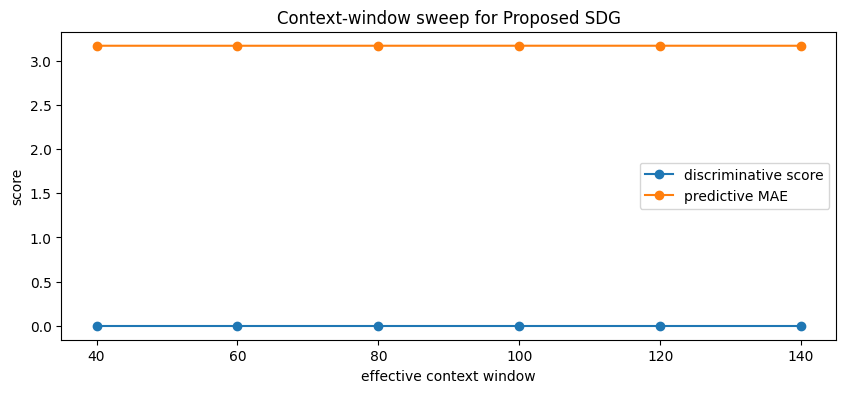

In [17]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    real_reference = get_real_reference(benchmark_results)

    utility_rows = []
    for name, payload in benchmark_results.items():
        pred_score = posthoc_rnn_predictive_score(real_reference, payload["syn_arr"], epochs=12, hidden_dim=32, batch_size=32, seed=BENCHMARK_SEED)
        forecast_score = xgboost_forecasting_score(real_reference, payload["syn_arr"], seed=BENCHMARK_SEED)
        utility_rows.append({
            "model": display_name(name),
            "predictive_mae_rnn": pred_score.get("mae", np.nan),
            "predictive_rmse_rnn": pred_score.get("rmse", np.nan),
            "forecast_mae_xgb": forecast_score.get("mae", np.nan),
            "forecast_rmse_xgb": forecast_score.get("rmse", np.nan),
            "forecast_model_family": forecast_score.get("model_family", "xgboost"),
        })

    utility_df = pd.DataFrame(utility_rows).sort_values("predictive_mae_rnn")
    display(utility_df)
    utility_df.to_csv(OUT_DIR / "paper_utility_scores.csv", index=False)

    # Context-window sweep for proposed SDG
    CONTEXT_SWEEP_VALUES = [40, 60, 80, 100, 120, CONTEXT_LENGTH]
    CONTEXT_SWEEP_MAX_SKUS = 8

    if MODEL_READY:
        sweep_skus = list(TEST_SKUs)[:CONTEXT_SWEEP_MAX_SKUS]
        context_sweep_rows = []
        for ctx_len in CONTEXT_SWEEP_VALUES:
            real_list = []
            syn_list = []
            for sku in sweep_skus:
                sku_df = make_daily_series(panel, sku, SKU_COL, TIME_COL, PRICE_COL, DEMAND_COL)
                decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
                sku_train = sku_df[sku_df[TIME_COL] <= decision_date].copy()
                sku_test = sku_df[sku_df[TIME_COL] > decision_date].copy()
                if len(sku_train) < max(10, ctx_len) or len(sku_test) < PREDICTION_LENGTH:
                    continue

                short_context = sku_train[DEMAND_COL].astype(float).values[-ctx_len:]
                if len(short_context) < CONTEXT_LENGTH:
                    pad_val = float(short_context[0]) if len(short_context) else 0.0
                    short_context = np.concatenate([np.repeat(pad_val, CONTEXT_LENGTH - len(short_context)), short_context])

                context_dates = sku_train[TIME_COL].iloc[-min(len(sku_train), CONTEXT_LENGTH):].tolist()
                if len(context_dates) < CONTEXT_LENGTH:
                    last_dt = pd.to_datetime(sku_train[TIME_COL].iloc[-1])
                    context_dates = pd.date_range(end=last_dt, periods=CONTEXT_LENGTH, freq="D").tolist()

                future_dates = sku_test[TIME_COL].iloc[:PREDICTION_LENGTH].tolist()
                real_future = sku_test[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH]

                try:
                    out = generate_proposed_sdg(
                        context_values=short_context,
                        context_dates=context_dates,
                        future_dates=future_dates,
                        horizon=PREDICTION_LENGTH,
                        metadata=None,
                    )
                    syn_future = np.asarray(out["best_future"], dtype=float)
                    real_list.append(real_future)
                    syn_list.append(syn_future)
                except Exception as exc:
                    warnings.warn(f"Context sweep failed for SKU {sku} at context={ctx_len}: {exc}")

            if len(real_list):
                real_arr_ctx = np.asarray(real_list, dtype=float)
                syn_arr_ctx = np.asarray(syn_list, dtype=float)
                disc = posthoc_rnn_discriminative_score(real_arr_ctx, syn_arr_ctx, epochs=10, hidden_dim=24, batch_size=16, seed=BENCHMARK_SEED)
                pred = posthoc_rnn_predictive_score(real_arr_ctx, syn_arr_ctx, epochs=10, hidden_dim=24, batch_size=16, seed=BENCHMARK_SEED)
                context_sweep_rows.append({
                    "context_window": int(ctx_len),
                    "n_eval_skus": int(len(real_arr_ctx)),
                    "discriminative_score_rnn": disc.get("score", np.nan),
                    "predictive_mae_rnn": pred.get("mae", np.nan),
                })

        context_sweep_df = pd.DataFrame(context_sweep_rows).sort_values("context_window")
        display(context_sweep_df)
        if len(context_sweep_df):
            plt.figure(figsize=(10, 4))
            plt.plot(context_sweep_df["context_window"], context_sweep_df["discriminative_score_rnn"], marker="o", label="discriminative score")
            plt.plot(context_sweep_df["context_window"], context_sweep_df["predictive_mae_rnn"], marker="o", label="predictive MAE")
            plt.xlabel("effective context window")
            plt.ylabel("score")
            plt.title("Context-window sweep for Proposed SDG")
            plt.legend()
            plt.show()
        context_sweep_df.to_csv(OUT_DIR / "paper_context_window_sweep.csv", index=False)
    else:
        print("Context-window sweep skipped because the proposed SDG model is not ready.")
else:
    print("Paper-aligned utility block skipped because benchmark results are not available.")

### 14.3 Privacy

This block adds a *privacy* against inference benchmark with four attack models:
- NumericalMLP,
- NumericalLR,
- NumericalSVR,
- NumericalRadNN.

Lower attack performance indicates that the generated data is less useful for reconstructing held-out target values from observed prefixes.


/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum i

,train_source,attack_model,mae,rmse
0,real_train_baseline,NumericalMLP,62.093548,70.248123
1,real_train_baseline,NumericalLR,4.270851,5.906744
2,real_train_baseline,NumericalSVR,2.983822,5.031237
3,real_train_baseline,NumericalRadNN,3.027179,4.892381
4,Proposed SDG,NumericalMLP,4.943222,5.897881
5,Proposed SDG,NumericalLR,3.981776,5.638232
6,Proposed SDG,NumericalSVR,3.076273,5.169133
7,Proposed SDG,NumericalRadNN,2.972147,4.657230
8,GAN,NumericalMLP,168.787437,169.936971
9,GAN,NumericalLR,146.589507,227.915384


Privacy-against-inference MAE table


train_source,DGAN,GAN,LSTM,Proposed SDG,TimeGAN,real_train_baseline
attack_model,,,,,,
NumericalLR,41.070237,146.589507,42.350039,3.981776,2.989233,4.270851
NumericalMLP,28.258680,168.787437,183.786369,4.943222,3.888407,62.093548
NumericalRadNN,28.661693,145.124525,149.130571,2.972147,3.914815,3.027179
NumericalSVR,28.259561,144.028219,148.465071,3.076273,3.858143,2.983822


Privacy gain relative to the held-out real-data baseline


,train_source,attack_model,mae,baseline_mae,privacy_gain,privacy_gain_capped
0,DGAN,NumericalLR,41.070237,4.270851,9.616407,9.616407
1,DGAN,NumericalMLP,28.258680,62.093548,0.455098,0.455098
2,DGAN,NumericalRadNN,28.661693,3.027179,9.468120,9.468120
3,DGAN,NumericalSVR,28.259561,2.983822,9.470927,9.470927
4,GAN,NumericalLR,146.589507,4.270851,34.323257,10.000000
5,GAN,NumericalMLP,168.787437,62.093548,2.718277,2.718277
6,GAN,NumericalRadNN,145.124525,3.027179,47.940518,10.000000
7,GAN,NumericalSVR,144.028219,2.983822,48.269709,10.000000
8,LSTM,NumericalLR,42.350039,4.270851,9.916066,9.916066
9,LSTM,NumericalMLP,183.786369,62.093548,2.959830,2.959830


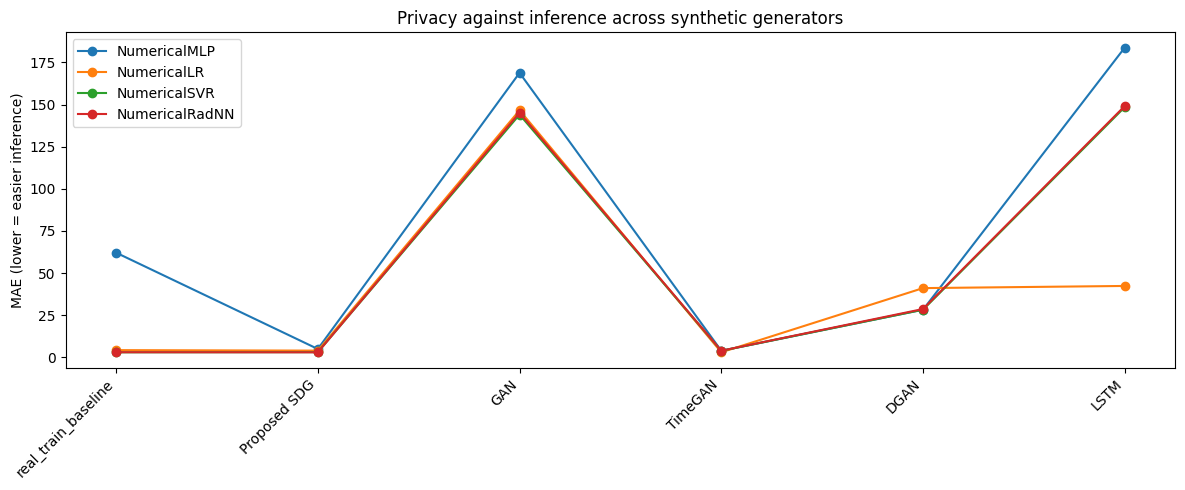

In [18]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    privacy_df = privacy_inference_block(benchmark_results, seed=BENCHMARK_SEED)
    if len(privacy_df):
        display(privacy_df)
        privacy_df.to_csv(OUT_DIR / "paper_privacy_inference.csv", index=False)

        pivot_mae = privacy_df.pivot(index="attack_model", columns="train_source", values="mae")
        print("Privacy-against-inference MAE table")
        display(pivot_mae)

        privacy_gain_df = privacy_gain_summary(privacy_df)
        if len(privacy_gain_df):
            print("Privacy gain relative to the held-out real-data baseline")
            display(privacy_gain_df)

        plt.figure(figsize=(12, 5))
        for attack_name in privacy_df["attack_model"].dropna().unique():
            sub = privacy_df[privacy_df["attack_model"] == attack_name]
            plt.plot(sub["train_source"], sub["mae"], marker="o", label=attack_name)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("MAE (lower = easier inference)")
        plt.title("Privacy against inference across synthetic generators")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Privacy-against-inference block produced no rows.")
else:
    print("Paper-aligned privacy block skipped because benchmark results are not available.")

## 15) Final dimension scores and overall benchmark ranking

This section aggregates the metrics into three dimension scores:
- *Fidelity*: how closely the synthetic series preserves the real distribution and temporal structure;
- *Utility*: how useful the synthetic data is for downstream prediction and forecasting;
- *Privacy*: how hard it is for post hoc attack models to infer held-out targets from synthetic data.

Each dimension score is computed on a *0–100* scale using normalized rank-based scoring across the compared models. A higher score is better. The overall score is the unweighted mean of the three dimensions.


,model,fidelity_score,utility_score,privacy_score,overall_score
0,DGAN,50.0,57.5,69.473756,58.991252
1,Proposed SDG,85.0,80.0,0.000000,55.000000
2,GAN,37.5,20.0,79.772990,45.757663
3,LSTM,27.5,25.0,80.210824,44.236941
4,TimeGAN,50.0,67.5,0.000000,39.166667


<Figure size 1000x500 with 0 Axes>

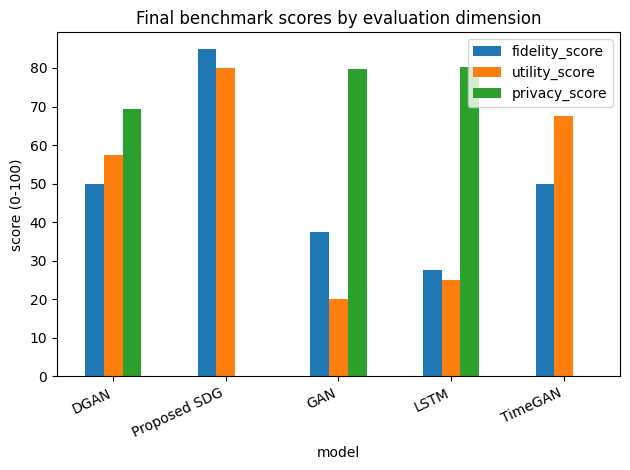

Best fidelity model: Proposed SDG
Best utility model: Proposed SDG
Best privacy model: LSTM


In [19]:
def _rank_score(values, higher_is_better=True, ideal=None):
    s = pd.to_numeric(pd.Series(values), errors="coerce")
    valid = s.notna()
    out = pd.Series(np.nan, index=s.index, dtype=float)
    if valid.sum() == 0:
        return out
    work = s[valid].astype(float)
    if ideal is not None:
        work = (work - float(ideal)).abs()
        higher_is_better = False
    if valid.sum() == 1:
        out.loc[valid] = 1.0
        return out
    ranks = work.rank(method="average", ascending=not higher_is_better)
    out.loc[valid] = 1.0 - (ranks - 1.0) / (len(work) - 1.0)
    return out

def _safe_merge(base_df, other_df, columns, on="model"):
    keep = [c for c in columns if c in other_df.columns]
    if not keep:
        return base_df
    merge_cols = [on] + keep
    return base_df.merge(other_df[merge_cols], on=on, how="left")

if RUN_BENCHMARK_COMPARISON and benchmark_results and "fidelity_summary_df" in globals() and "discriminative_df" in globals() and "utility_df" in globals() and "privacy_df" in globals():
    fidelity_df = fidelity_summary_df.copy()
    fidelity_df["model"] = fidelity_df["model"].replace(MODEL_DISPLAY_NAMES)

    discriminative_df_sc = discriminative_df.copy()
    if "model" in discriminative_df_sc.columns:
        discriminative_df_sc["model"] = discriminative_df_sc["model"].replace(MODEL_DISPLAY_NAMES)

    utility_df_sc = utility_df.copy()
    if "model" in utility_df_sc.columns:
        utility_df_sc["model"] = utility_df_sc["model"].replace(MODEL_DISPLAY_NAMES)

    privacy_df_sc = privacy_df.copy()
    if "train_source" in privacy_df_sc.columns:
        privacy_df_sc["train_source"] = privacy_df_sc["train_source"].replace(MODEL_DISPLAY_NAMES)
    if "model" in privacy_df_sc.columns:
        privacy_df_sc["model"] = privacy_df_sc["model"].replace(MODEL_DISPLAY_NAMES)

    similarity_df_sc = similarity_df.copy() if "similarity_df" in globals() else pd.DataFrame(columns=["model"])
    if "model" in similarity_df_sc.columns:
        similarity_df_sc["model"] = similarity_df_sc["model"].replace(MODEL_DISPLAY_NAMES)

    privacy_gain_df = privacy_gain_summary(privacy_df_sc)
    privacy_agg = (
        privacy_gain_df.groupby("train_source", as_index=False)
        .agg(
            avg_privacy_attack_mae=("mae", "mean"),
            avg_privacy_gain=("privacy_gain_capped", "mean"),
        )
        .rename(columns={"train_source": "model"})
    )
    privacy_agg["privacy_score"] = 100.0 * (privacy_agg["avg_privacy_gain"] - 1.0) / 9.0
    privacy_agg["privacy_score"] = privacy_agg["privacy_score"].clip(0.0, 100.0)

    # Start from fidelity summary and enrich with metrics pulled from benchmark results / per-SKU tables.
    score_df = fidelity_df.copy()

    extra_rows = []
    for raw_name, payload in benchmark_results.items():
        model_name = display_name(raw_name)
        metrics_local = dict(payload.get("metrics", {}))
        per_sku_df = payload.get("per_sku", pd.DataFrame())
        extra_rows.append(
            {
                "model": model_name,
                "tstr_mae": metrics_local.get("tstr_mae", metrics_local.get("tstr", {}).get("mae", np.nan) if isinstance(metrics_local.get("tstr", {}), dict) else np.nan),
                "trts_mae": metrics_local.get("trts_mae", metrics_local.get("trts", {}).get("mae", np.nan) if isinstance(metrics_local.get("trts", {}), dict) else np.nan),
                "avg_rmse": float(per_sku_df["rmse"].mean()) if isinstance(per_sku_df, pd.DataFrame) and "rmse" in per_sku_df.columns and len(per_sku_df) else np.nan,
                "avg_mae": float(per_sku_df["mae"].mean()) if isinstance(per_sku_df, pd.DataFrame) and "mae" in per_sku_df.columns and len(per_sku_df) else np.nan,
            }
        )
    extra_metrics_df = pd.DataFrame(extra_rows)

    score_df = _safe_merge(score_df, extra_metrics_df, ["tstr_mae", "trts_mae", "avg_rmse", "avg_mae"])
    score_df = _safe_merge(score_df, discriminative_df_sc, ["discriminative_score_rnn"])
    score_df = _safe_merge(score_df, utility_df_sc, ["predictive_mae_rnn", "forecast_mae_xgb"])
    score_df = _safe_merge(score_df, privacy_agg, ["avg_privacy_attack_mae", "avg_privacy_gain", "privacy_score"])
    score_df = _safe_merge(score_df, similarity_df_sc, ["avg_cosine_similarity_windowed", "avg_jensen_shannon_distance_windowed"])

    # Fidelity: higher cosine, lower Wasserstein/JS/discriminative score, detection closer to 0.5.
    fidelity_components = pd.DataFrame({"model": score_df["model"]})
    if "wasserstein_distance" in score_df.columns:
        fidelity_components["wasserstein"] = _rank_score(score_df["wasserstein_distance"], higher_is_better=False)
    if "avg_cosine_similarity" in score_df.columns:
        fidelity_components["cosine"] = _rank_score(score_df["avg_cosine_similarity"], higher_is_better=True)
    if "avg_jensen_shannon_distance" in score_df.columns:
        fidelity_components["js"] = _rank_score(score_df["avg_jensen_shannon_distance"], higher_is_better=False)
    if "discriminative_score_rnn" in score_df.columns:
        fidelity_components["disc"] = _rank_score(score_df["discriminative_score_rnn"], higher_is_better=False)
    if "detection_auc" in score_df.columns:
        fidelity_components["auc_ideal"] = _rank_score(score_df["detection_auc"], ideal=0.5)
    fidelity_cols = [c for c in fidelity_components.columns if c != "model"]
    fidelity_components["fidelity_score"] = 100.0 * fidelity_components[fidelity_cols].mean(axis=1, skipna=True)

    # Utility: lower downstream predictive / transfer / held-out errors.
    utility_components = pd.DataFrame({"model": score_df["model"]})
    if "predictive_mae_rnn" in score_df.columns:
        utility_components["predictive_mae_rnn"] = _rank_score(score_df["predictive_mae_rnn"], higher_is_better=False)
    if "forecast_mae_xgb" in score_df.columns:
        utility_components["forecast_mae_xgb"] = _rank_score(score_df["forecast_mae_xgb"], higher_is_better=False)
    if "tstr_mae" in score_df.columns:
        utility_components["tstr_mae"] = _rank_score(score_df["tstr_mae"], higher_is_better=False)
    if "trts_mae" in score_df.columns:
        utility_components["trts_mae"] = _rank_score(score_df["trts_mae"], higher_is_better=False)
    if "avg_rmse" in score_df.columns:
        utility_components["avg_rmse"] = _rank_score(score_df["avg_rmse"], higher_is_better=False)
    utility_cols = [c for c in utility_components.columns if c != "model"]
    utility_components["utility_score"] = 100.0 * utility_components[utility_cols].mean(axis=1, skipna=True)

    # Privacy: score relative to the held-out real-data baseline.
    privacy_components = pd.DataFrame({"model": score_df["model"]})
    privacy_components["privacy_score"] = score_df["privacy_score"] if "privacy_score" in score_df.columns else np.nan

    final_score_df = score_df[["model"]].copy()
    final_score_df = final_score_df.merge(fidelity_components[["model", "fidelity_score"]], on="model", how="left")
    final_score_df = final_score_df.merge(utility_components[["model", "utility_score"]], on="model", how="left")
    final_score_df = final_score_df.merge(privacy_components[["model", "privacy_score"]], on="model", how="left")
    final_score_df["overall_score"] = final_score_df[["fidelity_score", "utility_score", "privacy_score"]].mean(axis=1, skipna=True)
    final_score_df = final_score_df.sort_values(["overall_score", "fidelity_score"], ascending=False).reset_index(drop=True)

    display(final_score_df)
    final_score_df.to_csv(OUT_DIR / "paper_final_dimension_scores.csv", index=False)

    plt.figure(figsize=(10, 5))
    score_plot = final_score_df.set_index("model")[["fidelity_score", "utility_score", "privacy_score"]]
    score_plot.plot(kind="bar")
    plt.ylabel("score (0-100)")
    plt.title("Final benchmark scores by evaluation dimension")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

    if len(final_score_df):
        best_fidelity = final_score_df.sort_values("fidelity_score", ascending=False).iloc[0]["model"]
        best_utility = final_score_df.sort_values("utility_score", ascending=False).iloc[0]["model"]
        best_privacy = final_score_df.sort_values("privacy_score", ascending=False).iloc[0]["model"]
        print("Best fidelity model:", best_fidelity)
        print("Best utility model:", best_utility)
        print("Best privacy model:", best_privacy)
else:
    print("Final dimension scoring skipped because one or more paper-aligned result tables are unavailable.")

In [20]:
if 'final_score_df' in globals() and isinstance(final_score_df, pd.DataFrame) and len(final_score_df):
    _fs = final_score_df.copy()
    top_overall = _fs.sort_values('overall_score', ascending=False).iloc[0]
    top_fidelity = _fs.sort_values('fidelity_score', ascending=False).iloc[0]
    top_utility = _fs.sort_values('utility_score', ascending=False).iloc[0]
    top_privacy = _fs.sort_values('privacy_score', ascending=False).iloc[0]

    proposed_row = _fs[_fs['model'] == 'Proposed SDG']
    if len(proposed_row):
        proposed_row = proposed_row.iloc[0]
        proposed_sentence = (
            f"The proposed model obtained a fidelity score of {proposed_row['fidelity_score']:.1f}, "
            f"a utility score of {proposed_row['utility_score']:.1f}, a privacy score of {proposed_row['privacy_score']:.1f}, "
            f"and an overall score of {proposed_row['overall_score']:.1f}. "
        )
    else:
        proposed_sentence = ""

    conclusion = (
        f"Table-based aggregation of the benchmark results shows that {top_overall['model']} achieved the best overall performance "
        f"with an overall score of {top_overall['overall_score']:.1f}. "
        f"In the fidelity dimension, the strongest model was {top_fidelity['model']} with a score of {top_fidelity['fidelity_score']:.1f}, "
        f"indicating the closest match to the real data distribution and temporal structure. "
        f"In the utility dimension, {top_utility['model']} obtained the best score of {top_utility['utility_score']:.1f}, "
        f"which reflects stronger downstream predictive usefulness. "
        f"In the privacy dimension, {top_privacy['model']} reached the highest score of {top_privacy['privacy_score']:.1f}, "
        f"suggesting stronger resistance to inference-based attacks. "
        f"{proposed_sentence}"
        "Overall, these results show that the compared methods show a trade-off between realism, downstream usefulness, and privacy preservation, "
        "while the proposed model can be positioned clearly within this three-dimensional evaluation framework."
    )
    print(conclusion)
else:
    print('Conclusion skipped because final_score_df is not available.')

Table-based aggregation of the benchmark results shows that DGAN achieved the best overall performance with an overall score of 59.0. In the fidelity dimension, the strongest model was Proposed SDG with a score of 85.0, indicating the closest match to the real data distribution and temporal structure. In the utility dimension, Proposed SDG obtained the best score of 80.0, which reflects stronger downstream predictive usefulness. In the privacy dimension, LSTM reached the highest score of 80.2, suggesting stronger resistance to inference-based attacks. The proposed model obtained a fidelity score of 85.0, a utility score of 80.0, a privacy score of 0.0, and an overall score of 55.0. Overall, these results show that the compared methods show a trade-off between realism, downstream usefulness, and privacy preservation, while the proposed model can be positioned clearly within this three-dimensional evaluation framework.
